# Name: Diana Achieng' Otieno
# Adm. no: 222658
# Course: Research Methods for Data Science and Analytics (CAT 1)
# Analyzing Consumer Engagement Probability and Subscription Conversion Using a Customer Data Platform in the Media Industry: Insights from Subscription Media Data

# 1. INTRODUCTION

## Background
In today’s fast changing and dynamic digital landscape, traditional media platforms, such as print and broadcast, are rapidly declining giving way to online and digital platforms, thus altering how people consume news and content. One such company, a key player in the digital media space, faces the problem of not just attracting visitors, but turning them into loyal, paying subscribers. While increased digital traffic is a positive trend, it doesn't automatically translate into sustainable revenue unless casual readers are successfully guided through the subscription funnel. Each user interaction (a session or article view) offers valuable and unique behavioral data that, when analyzed, can reveal what drives engagement and where users tend to drop off. Understanding these behavioral patterns is crutial for improving user retention, tailoring content to users, and optimizing their overall digital experience. This study leverages user sessions and the interaction of article data to explore the underlying drivers of subscriptions and cause of user disengagement. It also offers insights to help the company refine its digital strategy and grow its subscriber base.

# Abstract

This study analyzes user behavior in a digital media CDP to predict subscriptions using session and interaction data from March to May 2025. The study assesses the performance of four ML models, that is, Logistic Regression, Random Forest, Gradient Boosting, and XGBoost. The main purpose was to evaluate a binary classification task, which was identifying if a user was subscribed (1) or not subscribed (0). It is however, important to note that there was a 3rd arbitrary class (on the fence) introduced, for the benefit of the marketing department. This was to help them identify the intesity of marketing activities on each level. The models are assessed using accuracy, precision, recall, ROC AUC, and RMSE metrics. Gradient Boosting came out on top overally, with highest accuracy (73.32%) and the least RMSE (0.5165), an indication of superior predictive performance and minimal error in probability estimates. Logistic Regression, on the other hand, excelled in recall (100%), ensuring all positive cases were captured (meaning it made sure it caught every positive case), while Random Forest showed the highest precision (74.39%), minimizing false positives (that is, false alarms). ROC AUC scores, ranging from 73.38% to 74.68%, suggest that all the models perform relatively well, with Logistic Regression and Gradient Boosting leading the pact. The findings highlight gradient boosting as the most balanced model, with Logistic Regression as a strong, interpretable alternative. Gradient Boosting is, therefore, recommended for its overall effectiveness, with Logistic Regression as a strong alternative for maximizing subscriber detection.

## Research Problem
While digital platforms often attract high volumes of traffic, the majority of users tend to leave after only one or two visits, rarely returning or converting into paying subscribers. This temporary engagement highlights a great challenge for digital publishers who largely rely on subscription-based models for revenue growth and sustainability. The main issue not only lies in attracting visitors, but also understanding why they leave so quickly and what might compel them to stay. Without a clear grasp of user behavior, such as when users are most active, how they interact with content, and at what point they tend to drop off, media organizations are essentially flying blind. Guesswork becomes the default approach to retention strategies, often leading to inefficient resource allocation and missed opportunities. The lack of in depth insight into the user journey thwarts efforts to personalize content, improve user experience, and design effective subscription funnels. By analyzing detailed session level data, this study seeks to uncover the behavioral patterns and bottlenecks that affect user engagement and conversion. In the long run, it aims to empower the media company with actionable insights to enhance digital retention, drive subscriptions, and sustain long term online growth. Beyond describing current behaviour, there is also a need to build predictive models that can estimate the likelihood of a user subscribing based on their past interactions, enabling targeted interventions to improve conversion rates.

## Objectives
1. To explore how users interact with content across their sessions and identify how long they stay engaged.

2. To find out how many sessions or days it typically takes for a user to subscribe.

3. To visualize where users drop off in the engagement funnel.
4. To understand which authors or content drive subscription the most
5. To prepare the dataset for machine learning, paving the way for smarter predictions.
6. To develop and gauge a machine learning model that could predict the probability of a user subscribing based on their interaction history and profile.

# 2. METHODOLOGY, RESULTS AND DISCUSSION

# Data Description

| COLUMN NAME                                    | DESCRIPTION                                                     |
| ---------------------------------------------------- | ----------------------------------------------------------------- |
| `user_id`                                            | Unique identifier for the session's user (anonymized).            |
| `session_creation_date`                              | Timestamp when the session was initiated.                         |
| `session_subscription_status`                        | Whether the session user is `anonymous` or `subscribed`.          |
| `country`, `city`                                    | User's geographical location during the session.                  |
| `interaction_id`                                     | Unique ID for an interaction (e.g., a page view or click).        |
| `event`, `event_id`, `event_time`                    | Event type (e.g., "page\_view"), event identifier, and timestamp. |
| `article_id`, `article_title`                        | Web address and metadata of the content being interacted with.    |
| `article_publish_date`                               | When the article was published.                                   |
| `subscription_date`                                  | When the subscription was initiated (if any).                     |
| `subscribed_article_id`, `subscribed_article_title`  | Article linked to the subscription (where applicable).            |
| `subscribed_user_id`                                 | User ID who subscribed (can be linked to user\_id).               |
| `expiry_date`, `purchase_date`                       | Subscription's expiration and initial payment date.               |
| `package_type`                                       | Subscription type: `DAILY`, `WEEKLY`, `MONTHLY`, etc.             |
| `amount_paid`                                        | Price paid for the subscription.                                  |
| `payment_option`                                     | Payment method used, i.e., `M-PESA`or `DPO (an app)`.             |


**Source of Data:** This was pulled directly from the customer data platform logs (excluding the names, and phone numbers for privacy reasons). Some of the columns included the tracking sessions, article reads, and purchases.

**Timeframe/ Period collected (year and month/day):** Due to the large nature of the information, the data only spans across 3 months (6th March 2025 to 24th May 2025). This represented the first 1 million rows of the SQL query exectuted on the database

**How it was collected:** The data was collected from every action a user takes (like visiting a page, reading an article, subscribing) and was logged in by an analytics system embedded in the website. The data was then stored in the company's database from where a SQL query was written to retrieve this the first one million rows and was then written to a csv file for analysis

**Conditions:** The data reflects organic user behavior; no promotional campaigns or experiments were running during collection.

In [1]:
#!pip install brokenaxes

In [2]:
# Installing the required libraries
import pandas as pd
import missingno as msno
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from matplotlib.ticker import FuncFormatter
from brokenaxes import brokenaxes

# Function to format y-axis ticks to 'K'
formatter = FuncFormatter(lambda x, _: f'{x/1000:,.0f}K')

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

### Importing Data

In [3]:
#Importing the data to Jupyter Notebook
cdp_data = pd.read_excel('cdp_data.xlsx')

In [4]:
# Reading the first 5 rows of the data
cdp_data.head()

,user_id,session_creation_date,session_subscription_status,country,city,platform,channel,interaction_id,session_id,page_section,interaction_creation_date,article_id,content_type,article_title,article_tags,authors,article_publish_date,subscription_date,subscribed_article_id,subscribed_article_title,subscribed_user_id,expiry_date,purchase_date,package_type,amount_paid,payment_option
0,67cbb5acc128f2cfe1d83341,2025-04-25 13:24:44.967,anonymous,Somalia,Mogadishu,NATION_AFRICA,website,8d6fc7b5-c1b7-4a94-8127-dd2df93da226,2e5a9c54-e844-4503-a8fb-6b4e242b7bda,Life &amp; Style,2025-04-25 13:26:46.037,5016724,1.0,â€˜I was scammed in CBEX get-rich-quick dreamâ€™,"{Prime,Lifestyle,""Help Me"",""Educate Me"",Kenya}",Jackson Ngari,2025-04-25 09:47:29,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
1,67cbb5acc128f2cfe1d83341,2025-04-25 13:24:44.967,anonymous,Somalia,Mogadishu,NATION_AFRICA,website,8cf2bdf0-8197-427f-904f-5d1dd84ea3c3,2e5a9c54-e844-4503-a8fb-6b4e242b7bda,Life &amp; Style,2025-04-25 13:25:48.741,5016724,1.0,â€˜I was scammed in CBEX get-rich-quick dreamâ€™,"{Prime,Lifestyle,""Help Me"",""Educate Me"",Kenya}",Jackson Ngari,2025-04-25 09:47:29,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
2,67c9a4dfc128f2cfe1ae4cd7,2025-04-25 13:25:14.284,anonymous,United Kingdom,London,NATION_AFRICA,website,eae33081-19eb-4641-993d-23e564f2d222,7a90c85d-c759-4e5a-8428-e88730ba278e,News,2025-04-25 13:27:48.491,5017076,0.0,"Ruto concludes China visit, to return over the...","{""""}",NaN,2025-04-25 12:08:56,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
3,67c9a4dfc128f2cfe1ae4cd7,2025-04-25 13:25:14.284,anonymous,United Kingdom,London,NATION_AFRICA,website,4771714e-f62e-446a-9a77-2a683d5d8760,7a90c85d-c759-4e5a-8428-e88730ba278e,News,2025-04-25 13:26:15.487,5016556,1.0,"Come out and save us, you have the numbers, Uh...","{""Makerere University"",Universities,""Update Me""}",Victor Raballa,2025-04-25 07:14:49,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
4,67c9a4dfc128f2cfe1ae4cd7,2025-04-25 13:25:14.284,anonymous,United Kingdom,London,NATION_AFRICA,website,41291372-962c-4eb7-b8f0-36239b1ae427,7a90c85d-c759-4e5a-8428-e88730ba278e,Diaspora News,2025-04-25 13:25:30.130,5016832,1.0,"Kenyan murdered by ex-lover in Minnesota, US, ...","{""Diaspora News"",""Update Me"",DigiFirst,""United...",Hilary Kimuyu,2025-04-25 10:41:40,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN


## Data Cleaning

In [5]:
cdp_data.columns

Index(['user_id', 'session_creation_date', 'session_subscription_status',
       'country', 'city', 'platform', 'channel', 'interaction_id',
       'session_id', 'page_section', 'interaction_creation_date', 'article_id',
       'content_type', 'article_title', 'article_tags', 'authors',
       'article_publish_date', 'subscription_date', 'subscribed_article_id',
       'subscribed_article_title', 'subscribed_user_id', 'expiry_date',
       'purchase_date', 'package_type', 'amount_paid', 'payment_option'],
      dtype='str')

In [6]:
cdp_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   user_id                      1000000 non-null  str           
 1   session_creation_date        1000000 non-null  datetime64[us]
 2   session_subscription_status  1000000 non-null  str           
 3   country                      977064 non-null   str           
 4   city                         977064 non-null   str           
 5   platform                     1000000 non-null  str           
 6   channel                      1000000 non-null  str           
 7   interaction_id               1000000 non-null  str           
 8   session_id                   1000000 non-null  str           
 9   page_section                 1000000 non-null  str           
 10  interaction_creation_date    1000000 non-null  datetime64[us]
 11  article_id             

In [7]:
#find which columns contains lists
for col in cdp_data.columns:
    if cdp_data[col].apply(lambda x: isinstance(x, list)).any():
        print(f"Column '{col}' contains list objects")

In [8]:
#Convert list columns to strings
for col in cdp_data.columns:
    if cdp_data[col].apply(lambda x: isinstance(x, list)).any():
        cdp_data[col] = cdp_data[col].astype(str)  # convert list to string

In [9]:
# Shape and data types
print("Initial Shape of data:", cdp_data.shape)
print("\nColumn Data Types:\n", cdp_data.dtypes)
# Summary statistics
print("\nDescriptive Statistics:\n", cdp_data.describe(include='all'))


Initial Shape of data: (1000000, 26)

Column Data Types:
 user_id                                   str
session_creation_date          datetime64[us]
session_subscription_status               str
country                                   str
city                                      str
platform                                  str
channel                                   str
interaction_id                            str
session_id                                str
page_section                              str
interaction_creation_date      datetime64[us]
article_id                              int64
content_type                          float64
article_title                          object
article_tags                              str
authors                                   str
article_publish_date           datetime64[us]
subscription_date              datetime64[us]
subscribed_article_id                 float64
subscribed_article_title                  str
subscribed_user_id    

In [10]:
# Check for duplicates
print("\nNumber of duplicate rows:", cdp_data.duplicated().sum())


Number of duplicate rows: 101961


In [11]:
#drop duplicate rows
cdp_data = cdp_data.drop_duplicates()

In [12]:
#Confirm the new number of rows and columns in the data
cdp_data.shape

(898039, 26)


Missing Value Report:
                           Missing Values    Percent
subscribed_article_title          420809  46.858655
subscribed_article_id             272384  30.330977
payment_option                    259864  28.936828
subscription_date                 210157  23.401768
subscribed_user_id                210157  23.401768
expiry_date                       210157  23.401768
purchase_date                     210157  23.401768
package_type                      210157  23.401768
amount_paid                       210157  23.401768
authors                            30678   3.416110
country                            19529   2.174627
city                               19529   2.174627
content_type                         204   0.022716


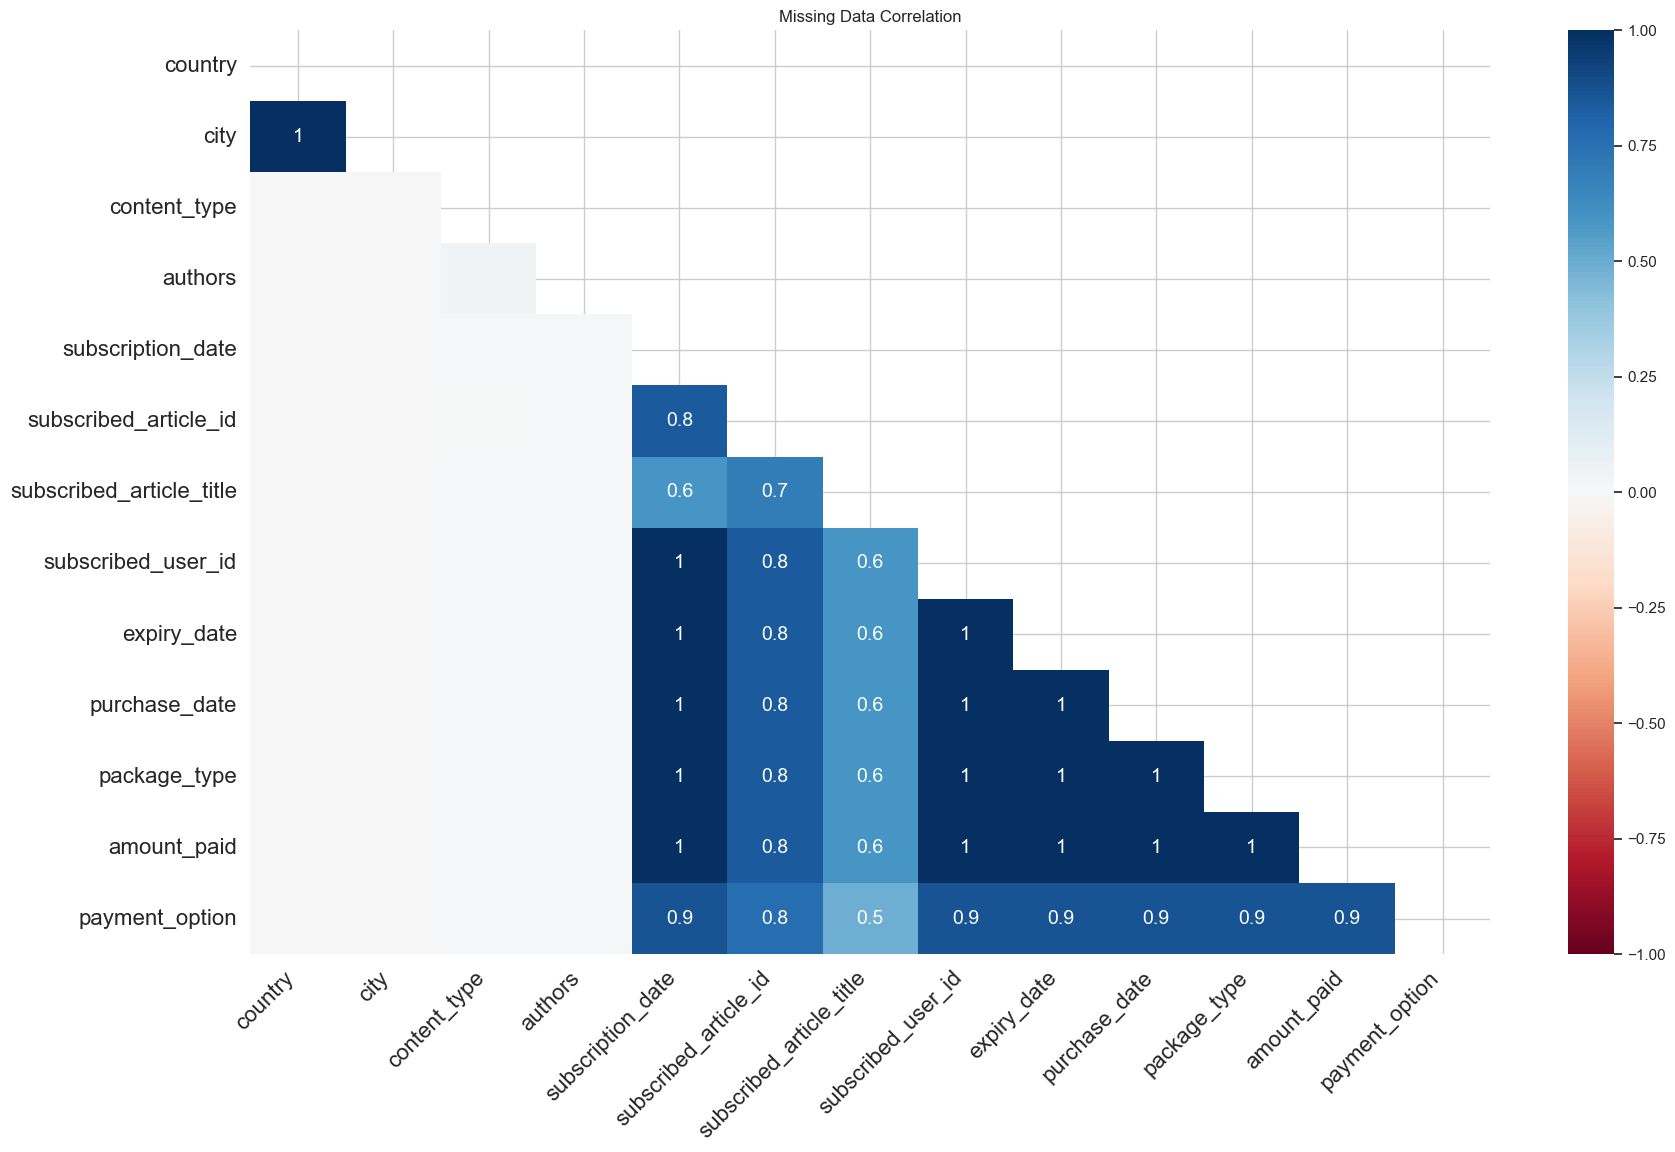

In [13]:
# Missing value count and percentage
missing = cdp_data.isnull().sum()
missing_percent = (missing / len(cdp_data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percent', ascending=False)

print("\nMissing Value Report:\n", missing_df)

# produce a heatmap showing nullity correlations (i.e., how the presence/absence of one column relates to another).
msno.heatmap(cdp_data.sample(898039))
plt.title("Missing Data Correlation")
plt.savefig('Correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


#### Dealing with missing values

subscribed_article_tittle is missing 100% of its value hence i will drop it

payment_option is missing 2.77% it is categorical data hence i will fill with 'Unknown'

country, city, author, content_type is missing ~4%. They are Categorical data hence i will use 'Unknown'

subscription_date, subscribed_article_id, subscribed_user_id, expiry_date, purchase_date, package_type, amount_paid use None as the user did not subscribe

In [14]:
#1. Drop the column with 100% missing values
cdp_data = cdp_data.drop(columns=['subscribed_article_title'])

# Fill missing values in 'payment_option' (2.77% missing) with 'Unknown'
cdp_data['payment_option'] = cdp_data['payment_option'].fillna('Unknown')

# Fill missing values in 'country' and 'city' (2.39% missing) with 'Unknown'
cdp_data['country'] = cdp_data['country'].fillna('Unknown')
cdp_data['city'] = cdp_data['city'].fillna('Unknown')
cdp_data['authors'] = cdp_data['authors'].fillna('Unknown')
cdp_data['content_type'] = cdp_data['content_type'].fillna('Unknown')

# Confirm changes
print(cdp_data.isnull().sum())

user_id                             0
session_creation_date               0
session_subscription_status         0
country                             0
city                                0
platform                            0
channel                             0
interaction_id                      0
session_id                          0
page_section                        0
interaction_creation_date           0
article_id                          0
content_type                        0
article_title                       0
article_tags                        0
authors                             0
article_publish_date                0
subscription_date              210157
subscribed_article_id          272384
subscribed_user_id             210157
expiry_date                    210157
purchase_date                  210157
package_type                   210157
amount_paid                    210157
payment_option                      0
dtype: int64


In [15]:
# Select numeric columns
numeric_cols = cdp_data.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)


['article_id', 'subscribed_article_id', 'amount_paid']


In [16]:
# List of subscription-related columns
subscription_cols = [
    'subscription_date',
    'subscribed_article_id',
    'subscribed_user_id',
    'expiry_date',
    'purchase_date',
    'package_type',
    'amount_paid'
]

# Fill missing values in these columns with np.nan 
cdp_data[subscription_cols] = cdp_data[subscription_cols].fillna(value=np.nan)  # used np.nan for numerical analysis

In [17]:
# Confirm changes
print(cdp_data.isnull().sum())

user_id                             0
session_creation_date               0
session_subscription_status         0
country                             0
city                                0
platform                            0
channel                             0
interaction_id                      0
session_id                          0
page_section                        0
interaction_creation_date           0
article_id                          0
content_type                        0
article_title                       0
article_tags                        0
authors                             0
article_publish_date                0
subscription_date              210157
subscribed_article_id          272384
subscribed_user_id             210157
expiry_date                    210157
purchase_date                  210157
package_type                   210157
amount_paid                    210157
payment_option                      0
dtype: int64


**Data type conversions** – Convert dates to `datetime` objects and amounts to numeric values.

In [18]:
# Convert date columns
date_cols = ['session_creation_date', 'interaction_creation_date','article_publish_date', 'subscription_date', 'expiry_date', 'purchase_date']
for col in date_cols:
    cdp_data[col] = pd.to_datetime(cdp_data[col], errors='coerce')

**Outliers check**

In [19]:
cdp_data['amount_paid'] = cdp_data['amount_paid'].replace([np.inf, -np.inf], np.nan)

In [20]:
#!pip install seaborn==0.13.2
#import seaborn as sns
#print(sns.__version__)

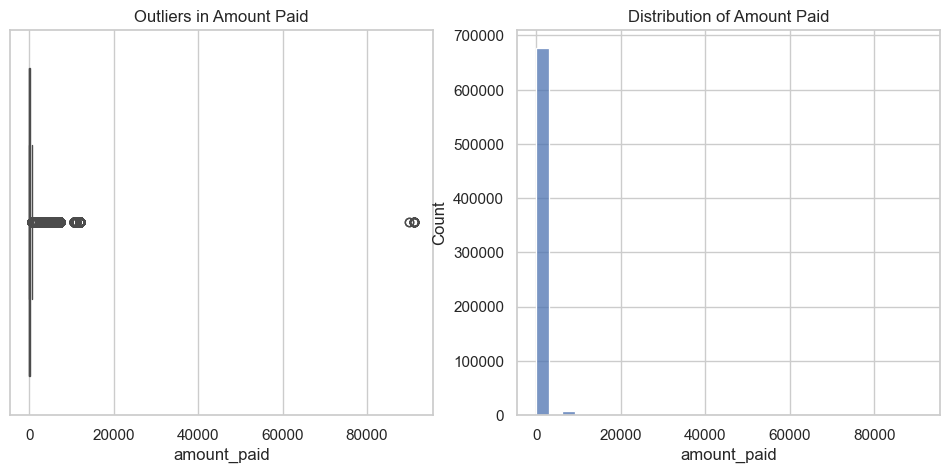

Amount Paid outliers: 110822 rows, outside [-295.00, 625.00]


In [21]:
# Session duration (in minutes) 
#    Assuming 'event_time' or last interaction timestamp exists
if 'event_time' in cdp_data.columns:
    cdp_data['event_time'] = pd.to_datetime(cdp_data['event_time'], errors='coerce')
    cdp_data['session_duration_minutes'] = (cdp_data['event_time'] - cdp_data['session_creation_date']).dt.total_seconds() / 60
else:
    # If no end time, we can skip or use subscription duration as a proxy
    cdp_data['session_duration_minutes'] = None

#  Amount Paid Outlier Check
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.boxplot(x=cdp_data['amount_paid'])
plt.title("Outliers in Amount Paid")

plt.subplot(1, 2, 2)
sns.histplot(cdp_data['amount_paid'], bins=30, kde=False)
plt.title("Distribution of Amount Paid")
plt.show()

# Session Duration Outlier Check (if available)
if cdp_data['session_duration_minutes'].notnull().any():
    plt.figure(figsize=(12,5))
    plt.subplot(1, 2, 1)
    sns.boxplot(x=cdp_data['session_duration_minutes'])
    plt.title("Outliers in Session Duration (Minutes)")

    plt.subplot(1, 2, 2)
    sns.histplot(cdp_data['session_duration_minutes'], bins=30, kde=True)
    plt.title("Distribution of Session Duration")
    plt.show()

# Identify extreme outliers numerically using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_paid, lb_paid, ub_paid = detect_outliers_iqr(cdp_data, 'amount_paid')
print(f"Amount Paid outliers: {outliers_paid.shape[0]} rows, outside [{lb_paid:.2f}, {ub_paid:.2f}]")

if cdp_data['session_duration_minutes'].notnull().any():
    outliers_session, lb_sess, ub_sess = detect_outliers_iqr(cdp_data, 'session_duration_minutes')
    print(f"Session Duration outliers: {outliers_session.shape[0]} rows, outside [{lb_sess:.2f}, {ub_sess:.2f}]")    
    

While the boxplot shows outliers, the distribution plot shows that the outliers are perfectly within the range of amount paid for the yearly subscription hence there is no need to act on them

In [22]:
print("Cleaned shape:", cdp_data.shape)

Cleaned shape: (898039, 26)


# Exploratory Data Analysis (EDA)

## Descriptive Analysis

In [23]:
cdp_data.describe()

,session_creation_date,interaction_creation_date,article_id,article_publish_date,subscription_date,subscribed_article_id,expiry_date,purchase_date,amount_paid
count,898039,898039,8.980390e+05,898039,687882,6.256550e+05,687882,687882,687882.000000
mean,2025-05-13 10:59:25.594102,2025-05-13 11:07:19.945292,4.994290e+06,2025-04-18 21:09:56.862852,2025-10-24 22:11:13.612328,5.195315e+06,2025-11-09 09:54:17.906040,2025-10-25 00:40:44.917204,383.761843
min,2025-04-01 00:01:24.386000,2025-04-01 00:02:11.081000,9.480000e+02,2020-03-16 14:30:52,2025-04-01 02:43:00.775000,5.298000e+03,2025-04-02 11:16:08,2025-04-01 05:42:16,0.000000
25%,2025-04-19 14:55:16.095000,2025-04-19 14:57:09.181000,5.005950e+06,2025-04-16 20:10:19,2025-08-04 04:36:38.057000,5.133096e+06,2025-08-14 06:37:02.750000,2025-08-04 07:28:30,50.000000
50%,2025-05-13 03:53:23.758000,2025-05-13 03:55:25.592000,5.035936e+06,2025-05-10 13:34:04,2025-11-04 07:28:05.913000,5.249302e+06,2025-11-15 12:06:45,2025-11-04 10:27:39,50.000000
75%,2025-06-06 08:59:35.409000,2025-06-06 09:10:26.610000,5.069328e+06,2025-06-04 20:49:35,2026-01-10 18:18:58.008000,5.317726e+06,2026-01-21 16:47:37,2026-01-10 20:20:53,280.000000
max,2025-06-29 23:52:28.487000,2025-06-29 23:56:04.050000,5.100550e+06,2025-08-07 13:10:44,2026-03-27 12:52:46.300000,5.404930e+06,2027-02-02 09:59:00,2026-03-27 15:52:24,91000.000000
std,NaN,NaN,3.963926e+05,NaN,NaN,3.869381e+05,NaN,NaN,1198.650256


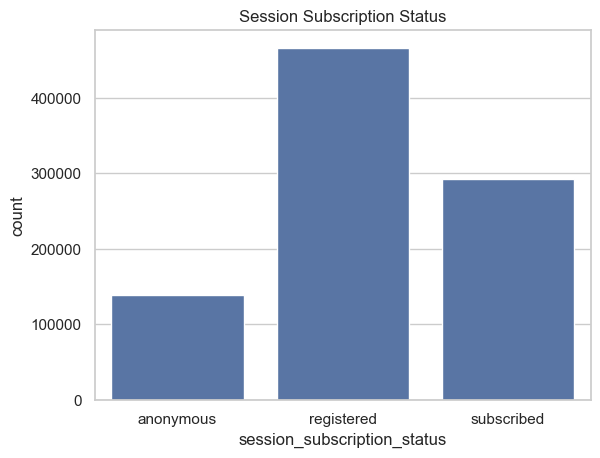

In [24]:
# Subscription status distribution
sns.countplot(x='session_subscription_status', data=cdp_data)
plt.title("Session Subscription Status")
plt.show()

C:\Users\dotieno\AppData\Local\Temp\ipykernel_4380\789022995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


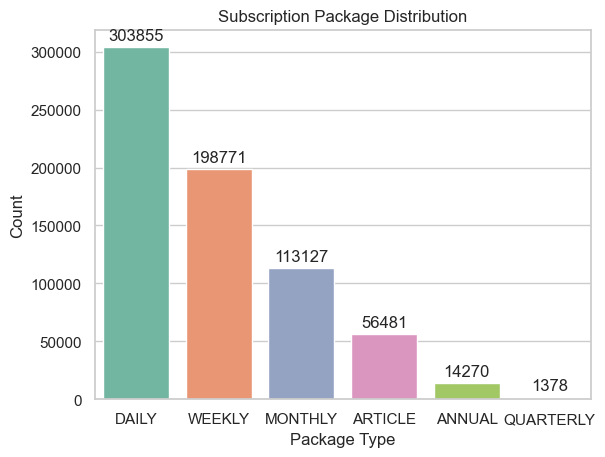

In [25]:
package_order = cdp_data['package_type'].value_counts().index
# Count plot for subscription package types
ax = sns.countplot(
    data=cdp_data,
    x='package_type',
    order=package_order,
    palette='Set2'
)

#ax = sns.countplot(data=cdp_data, x='package_type', palette='Set2')


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                xytext=(0, 5),  # 5 points vertical offset
                textcoords='offset points')
plt.title('Subscription Package Distribution')
plt.xlabel('Package Type')
plt.ylabel('Count')
plt.savefig('Subscription_Package_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Package vs Amount Paid

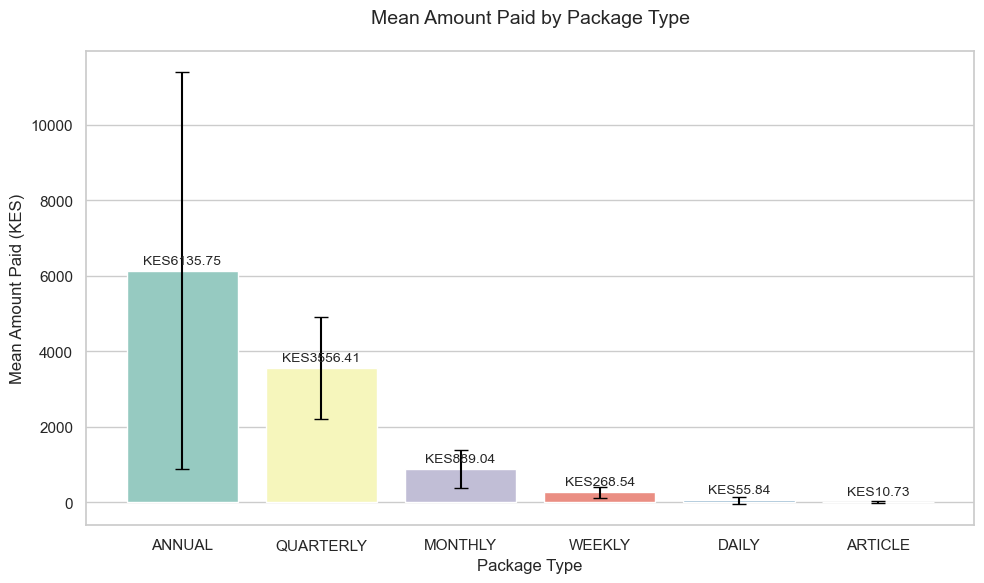

In [26]:
# Amount paid per package type
# Mean and std for each package
summary = cdp_data.groupby('package_type')['amount_paid'].agg(['mean', 'std']).reset_index()
# Sort by revenue
summary = summary.sort_values(by='mean', ascending=False)

# Set style and figure size
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create bar plot with error bars
ax = sns.barplot(data=summary, x='package_type', y='mean', hue='package_type', palette='Set3', 
                  errorbar=None, legend=False)
plt.errorbar(x=range(len(summary)), y=summary['mean'], yerr=summary['std'], fmt='none', capsize=5, color='black')

# Add mean labels on top
for i, bar in enumerate(ax.patches):
    ax.annotate(f'KES{bar.get_height():.2f}', 
                (bar.get_x() + bar.get_width() / 2., bar.get_height()), 
                ha='center', va='baseline', xytext=(0, 5), 
                textcoords='offset points', fontsize=10)

# Customize title and labels
plt.title('Mean Amount Paid by Package Type', fontsize=14, pad=20)
plt.xlabel('Package Type', fontsize=12)
plt.ylabel('Mean Amount Paid (KES)', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()

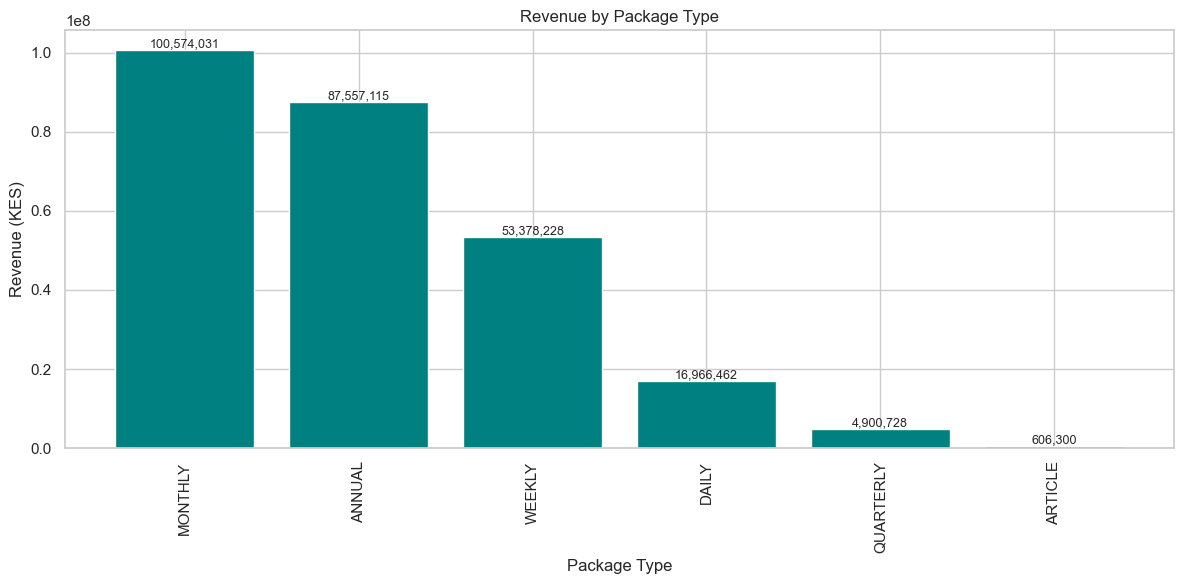

In [27]:

# Group and sum revenue per package type
package_revenue = cdp_data.groupby('package_type')['amount_paid'].sum().reset_index()
# Sort by revenue
package_revenue = package_revenue.sort_values(by='amount_paid', ascending=False)

# Plot
plt.figure(figsize=(12, 6))

bars = plt.bar(
    package_revenue['package_type'],
    package_revenue['amount_paid'],
    color='teal'
)

# Add totals on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Plot
plt.title('Revenue by Package Type')
plt.xlabel('Package Type')
plt.ylabel('Revenue (KES)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Revenue_by_package_type.png', dpi=300, bbox_inches='tight')
plt.show()

# Diagnostic Analysis

# Subscription, user behaviour and conversion funnel

In [28]:
# See how many unique users converted or did NOT convert
# Get all unique session users
all_users = set(cdp_data['user_id'].dropna().unique())

# Get all users who subscribed
subscribed_users = set(cdp_data['subscribed_user_id'].dropna().unique())

# Find the difference
non_converted_users = len(all_users) - len(subscribed_users)

# Users who converted
converted_users = subscribed_users  

all_users = len(all_users)
converted_users = len(subscribed_users)

# Print results
print(f"All Users: {all_users}, Non-Converted: {non_converted_users}, Converted: {converted_users}")

# Conversion rate
conversion_rate = (converted_users/all_users) * 100
print(f"Conversion Rate: {conversion_rate:.2f}%\n")

All Users: 63606, Non-Converted: 55435, Converted: 8171
Conversion Rate: 12.85%



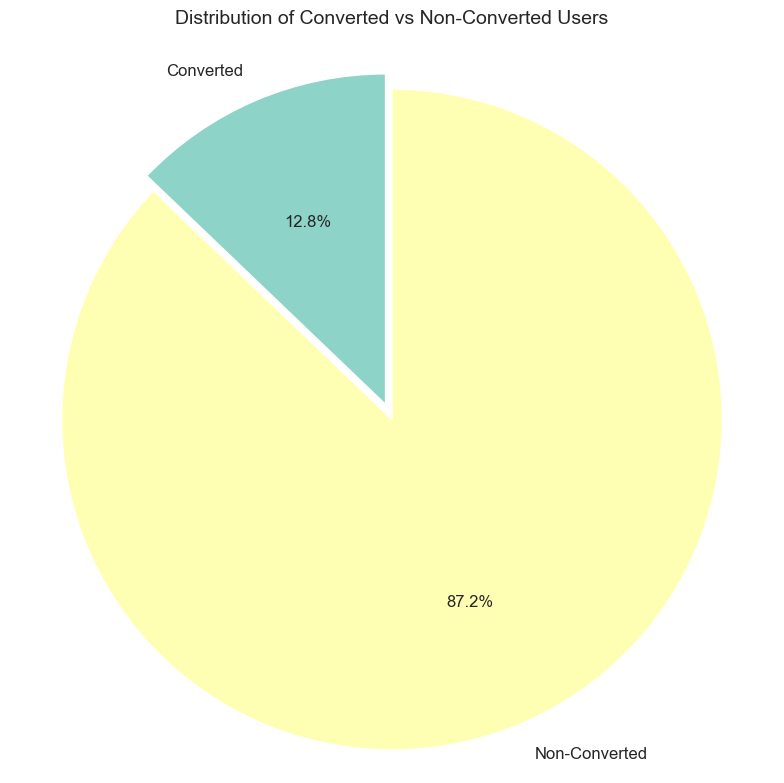

In [29]:
#  Create pie chart
# Set seaborn style for consistency
sns.set_style("white")

# Data for pie chart
labels = ['Converted', 'Non-Converted']
sizes = [converted_users, non_converted_users]
colors = sns.color_palette("Set3", n_colors=2)  # Use Set3 palette for consistency
explode = (0.05, 0)  # Slightly explode the Converted slice for emphasis

# Create figure
plt.figure(figsize=(8, 8))

# Plot pie chart
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=explode, 
        shadow=False, textprops={'fontsize': 12})

# Equal aspect ratio ensures pie is circular
plt.axis('equal')

# Add title
plt.title('Distribution of Converted vs Non-Converted Users', fontsize=14, pad=20)

# Show plot
plt.tight_layout()
plt.savefig('User_conversion_rate.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# Conversion based on the total sessions available
non_converted = cdp_data['subscription_date'].isnull().sum()
converted = cdp_data['subscription_date'].notnull().sum()
print(f"Converted: {converted}, Non-Converted: {non_converted}")

Converted: 687882, Non-Converted: 210157


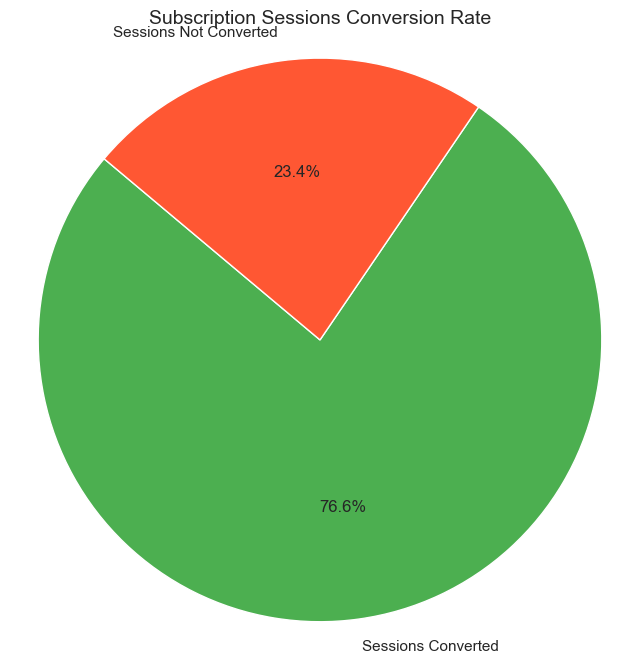

In [31]:
# Create 'converted' flag — True if subscription_date exists
cdp_data['sessions_converted'] = cdp_data['subscription_date'].notna()

# Count converted and non-converted users
conversion_counts = cdp_data['sessions_converted'].value_counts(normalize=True) * 100

# Prepare labels and values
labels = ['Sessions Converted', 'Sessions Not Converted']
sizes = [conversion_counts[True], conversion_counts[False]]
colors = ['#4CAF50', '#FF5733']

# Plotting
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%.1f%%', startangle=140)
plt.title('Subscription Sessions Conversion Rate', fontsize=14)
plt.axis('equal') 
plt.savefig('Session_conversion_rate.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# Time to conversion (in days)
first_visits = cdp_data.groupby('user_id')['session_creation_date'].min()
subscription_dates = cdp_data[cdp_data['subscription_date'].notna()].groupby('user_id')['subscription_date'].min()

# Only for converted users
conversion_time = (subscription_dates - first_visits[subscription_dates.index]).dt.days
print("Time to Conversion (days):")
print(conversion_time.describe(), "\n")

# Sessions before conversion
user_sessions = cdp_data.groupby('user_id')['session_id'].nunique()
sessions_before_conversion = user_sessions.reindex(subscription_dates.index, fill_value=0)
print("Sessions Before Conversion:")
print(sessions_before_conversion.describe(), "\n")

# Drop-off distribution — sessions for non-converted users
non_converted_ids = set(cdp_data['user_id']) - set(subscription_dates.index)
non_converted_sessions = user_sessions[user_sessions.index.isin(non_converted_ids)]
dropoff_distribution = non_converted_sessions.value_counts().sort_index()

print("Drop-off Points (Sessions Count for Non-Converted Users):")
print(dropoff_distribution.head(15))

Time to Conversion (days):
count    8171.000000
mean       85.686942
std        92.617714
min         0.000000
25%        14.000000
50%        37.000000
75%       160.000000
max       355.000000
dtype: float64 

Sessions Before Conversion:
count    8171.000000
mean        3.365194
std         3.143766
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        51.000000
Name: session_id, dtype: float64 

Drop-off Points (Sessions Count for Non-Converted Users):
session_id
1     36782
2      9585
3      4037
4      2115
5      1171
6       653
7       405
8       269
9       137
10       95
11       56
12       40
13       21
14       10
15        9
Name: count, dtype: int64


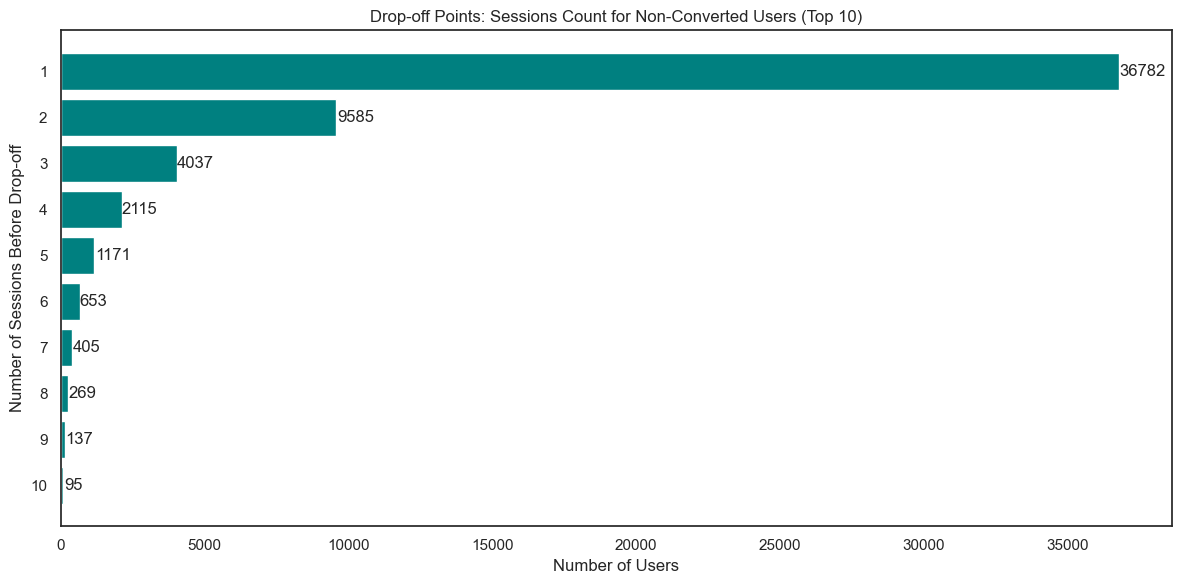

In [33]:
# Top N session buckets from drop-off distribution (Series)
top_n = 10
funnel_series = dropoff_distribution.head(top_n)

# Convert to DataFrame for plotting
funnel_df = funnel_series.reset_index()
funnel_df.columns = ['sessions', 'users']

# Sort by user count for funnel shape
funnel_df = funnel_df.sort_values('users', ascending=True)

# Plotting
plt.figure(figsize=(12, 6))
bars = plt.barh(funnel_df['sessions'].astype(str), funnel_df['users'], color='teal')
plt.xlabel("Number of Users")
plt.ylabel("Number of Sessions Before Drop-off")
plt.title("Drop-off Points: Sessions Count for Non-Converted Users (Top 10)")

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{int(width)}', va='center')

plt.tight_layout()
plt.savefig('non_converted_user_dropoff.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# Average sessions per user
avg_sessions_per_user = cdp_data.groupby('user_id')['session_id'].nunique().mean()
print(f"Average sessions per user: {avg_sessions_per_user:.2f}")

Average sessions per user: 1.94


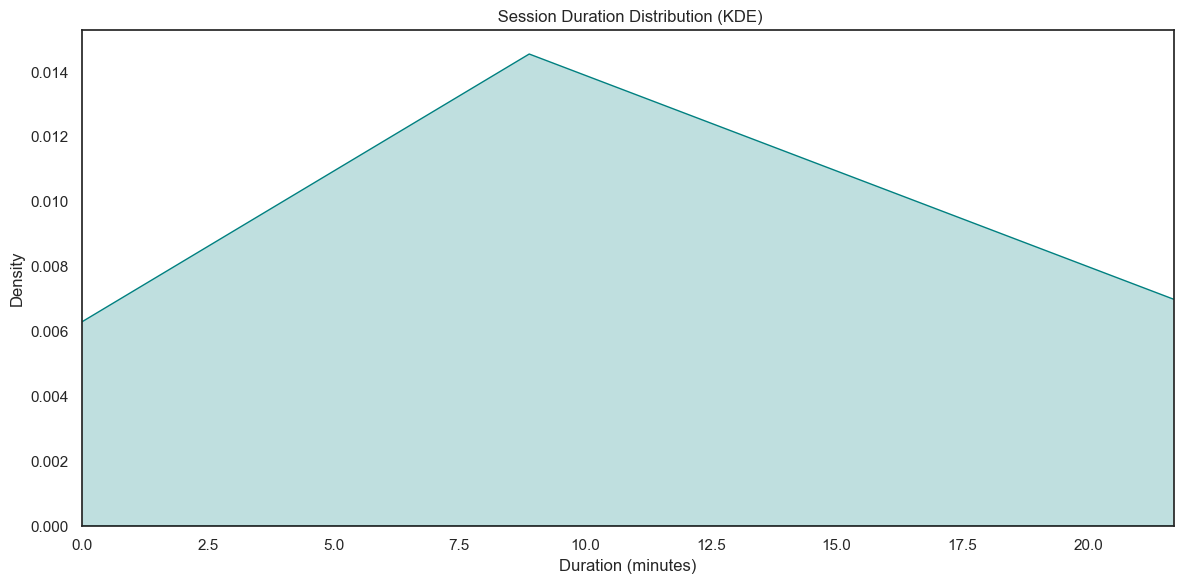

In [35]:
session_durations = cdp_data.groupby('session_id')['interaction_creation_date'].agg(['min', 'max'])
session_durations['duration_minutes'] = (session_durations['max'] - session_durations['min']).dt.total_seconds() / 60

# Plot distribution
plt.figure(figsize=(12, 6))
sns.kdeplot(session_durations['duration_minutes'].dropna(), fill=True, color='teal')
plt.title(" Session Duration Distribution (KDE)")
plt.xlabel("Duration (minutes)")
plt.xlim(0, session_durations['duration_minutes'].quantile(0.95))  # trim outliers
plt.tight_layout()
plt.show()

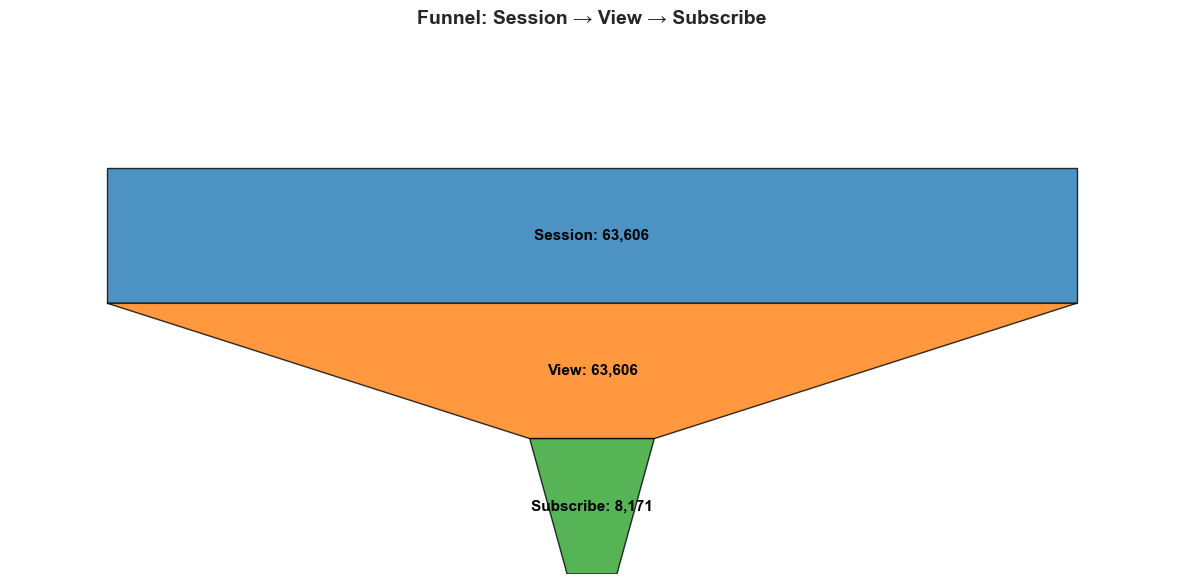

In [36]:
# A different way f building a funnel using matplotlib in case plotly does not show
from matplotlib.patches import Polygon

# --- Data ---
total_users = cdp_data['user_id'].nunique()
view_users = cdp_data[cdp_data['article_id'].notna()]['user_id'].nunique()
subscribed_users = cdp_data[cdp_data['subscription_date'].notna()]['user_id'].nunique()

stages = ['Session', 'View', 'Subscribe']
users = [total_users, view_users, subscribed_users]

# Normalize widths so the widest is full width
max_width = max(users)
widths = [u / max_width for u in users]

# Heights of each funnel section
height = 1.0

# Colors for each stage
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))
y = 0

for i in range(len(stages)):
    top_width = widths[i]
    bottom_width = widths[i+1] if i+1 < len(stages) else 0.4 * widths[i]  # last taper
    # Coordinates for trapezoid
    coords = [
        (-top_width/2, y),
        (top_width/2, y),
        (bottom_width/2, y - height),
        (-bottom_width/2, y - height)
    ]
    polygon = Polygon(coords, closed=True, facecolor=colors[i], edgecolor='black', alpha=0.8)
    ax.add_patch(polygon)
    
    # Add stage label
    ax.text(0, y - height/2, f"{stages[i]}: {users[i]:,}", 
            ha='center', va='center', fontsize=11, color='black', weight='bold')
    
    y -= height  # Move down for next stage

# Remove axes
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-len(stages)*height, 1)
ax.axis('off')

# Title
plt.title("Funnel: Session → View → Subscribe", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


## Authors by Subscription Revenue

In [37]:
Total_number_of_articles = cdp_data['article_id'].nunique()
Total_number_of_articles

9449

In [38]:
# Explode the authors so each author gets their share of the subscription revenue
cdp_data['num_authors'] = cdp_data['authors'].apply(len)
cdp_data['amount_per_author'] = cdp_data['amount_paid'] / cdp_data['num_authors']
cdp_data_exploded = cdp_data.explode('authors')
revenue_by_author = cdp_data_exploded.groupby('authors')['amount_per_author'].sum().reset_index()

# Group by author and sum the amount paid
revenue_by_author = cdp_data_exploded.groupby('authors')['amount_paid'].sum().reset_index()

# Sort descending by revenue
revenue_by_author = revenue_by_author.sort_values(by='amount_paid', ascending=False)

print(revenue_by_author)

                    authors  amount_paid
662           Joseph Wangui  14283911.20
1139                Reuters   9728737.00
1312                Unknown   8364601.87
990             Nation Team   6791794.88
1188           Sam Kiplagat   6371099.00
...                     ...          ...
346     Dr Oscar EV Magenya         0.00
341   Dr Geoffrey Githinjii         0.00
920          Michael Omondi         0.00
339        Dr Diallo Asseta         0.00
705     Kalume Kazungu, PCS         0.00

[1410 rows x 2 columns]


In [39]:
# Filter for authors with 0 revenue
zero_revenue_authors = revenue_by_author[revenue_by_author['amount_paid'] == 0]

# Show result
print("Authors with 0 revenue:")
print(zero_revenue_authors)

# Count number of authors with 0 revenue
num_zero_revenue_authors = zero_revenue_authors.shape[0]

print(f"Number of authors with 0 revenue: {num_zero_revenue_authors}")

Authors with 0 revenue:
                             authors  amount_paid
1151   Richard Munguti, Sam Kiplagat          0.0
63    Allan Olingo, Louise DonovanÂ           0.0
1138     Reginah Kinogu, LEOPOLD OBI          0.0
1137    Reginah Kinogu, Beth Wanjiku          0.0
1302      Tom Matoke, Stanley Kimuge          0.0
...                              ...          ...
346              Dr Oscar EV Magenya          0.0
341            Dr Geoffrey Githinjii          0.0
920                   Michael Omondi          0.0
339                 Dr Diallo Asseta          0.0
705              Kalume Kazungu, PCS          0.0

[528 rows x 2 columns]
Number of authors with 0 revenue: 528


In [40]:
# Drop authors with NaN values (no revenue at all)
revenue_by_author = revenue_by_author.dropna(subset=['authors','amount_paid'])

# Filter out authors with 0 or missing revenue
non_zero_revenue = revenue_by_author[revenue_by_author['amount_paid'] > 0]

# Sort for top and bottom authors
top_10 = non_zero_revenue.sort_values(by='amount_paid', ascending=False).head(10)
bottom_10 = non_zero_revenue.sort_values(by='amount_paid', ascending=True).head(10)
print(bottom_10)

                                               authors  amount_paid
812                        Lucas Barasa, George Munene         10.0
52                                         Alex Ndegwa         10.0
40   Aga Khan University Institute for Human Develo...         20.0
231                                  Christopher Mwiti         20.0
253                                        DAISY OKOTI         20.0
73                                  Andrew Ole Sunkuli         20.0
256                                        DAVID ADUDA         20.0
236                                    Collins Musanga         20.0
698                                     KINGWA KAMENCU         40.0
354                                       EGARA KABAJI         40.0


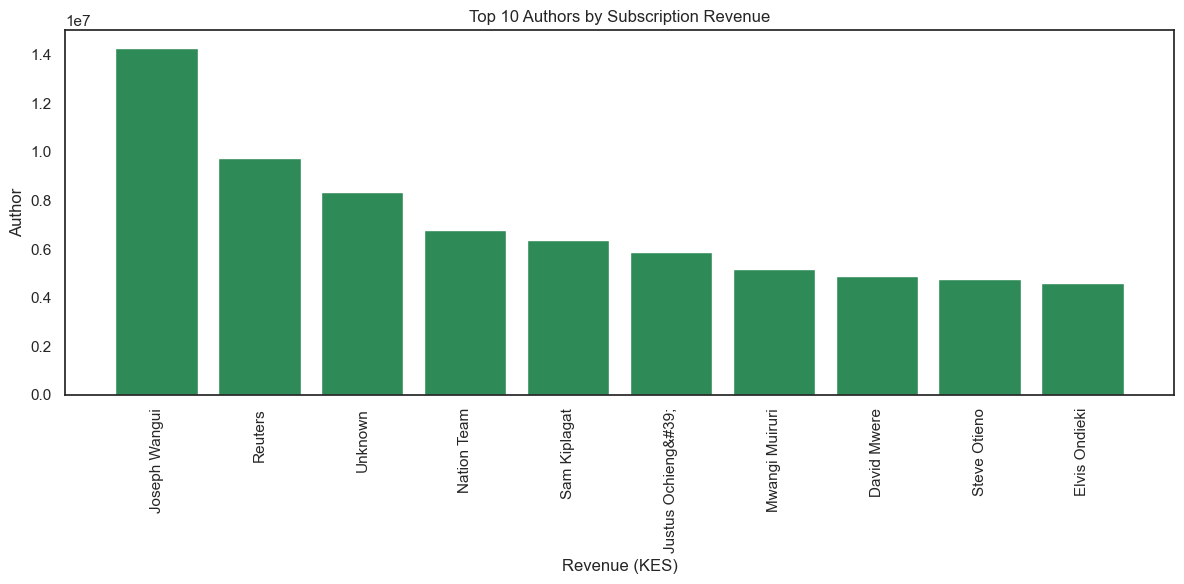

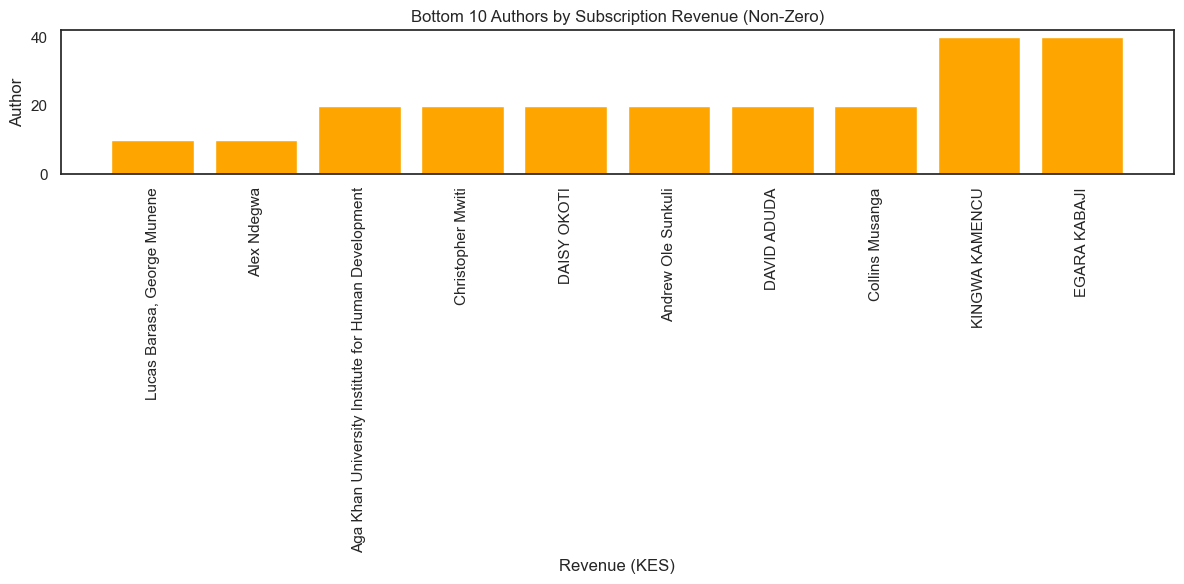

In [41]:
# Top 10 Authors
plt.figure(figsize=(12, 6))
plt.bar(top_10['authors'], top_10['amount_paid'], color='seagreen')
plt.title('Top 10 Authors by Subscription Revenue')
plt.xlabel('Revenue (KES)')
plt.ylabel('Author')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('authors_by_sub_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

# Bottom 10 Authors
plt.figure(figsize=(12, 6))
plt.bar(bottom_10['authors'], bottom_10['amount_paid'], color='orange')
plt.title('Bottom 10 Authors by Subscription Revenue (Non-Zero)')
plt.xlabel('Revenue (KES)')
plt.ylabel('Author')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


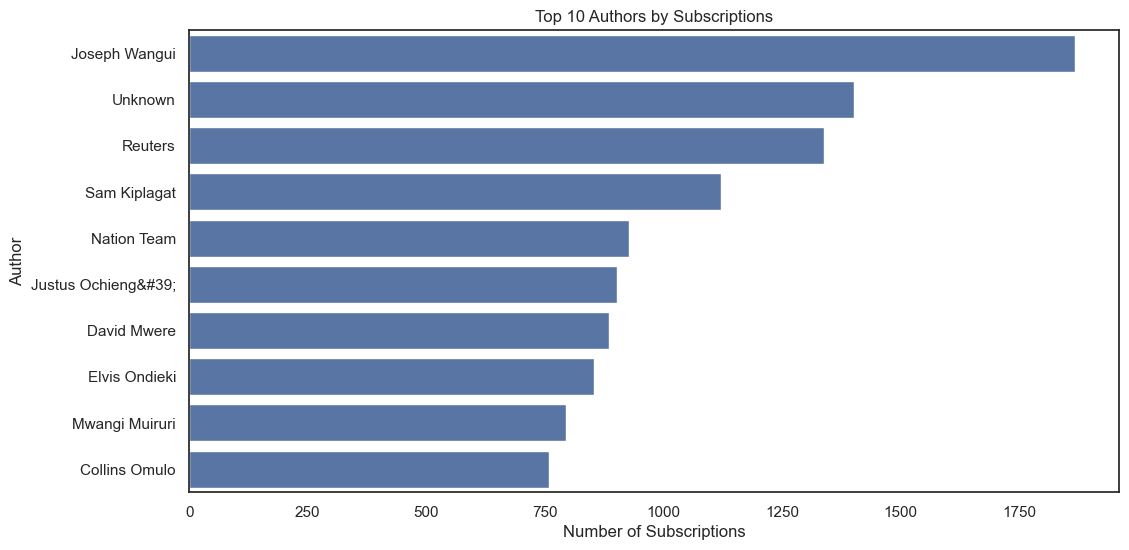

In [42]:
subscriptions_by_author = cdp_data.groupby('authors')['subscribed_user_id'].nunique().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=subscriptions_by_author.values, y=subscriptions_by_author.index)
plt.title('Top 10 Authors by Subscriptions')
plt.xlabel('Number of Subscriptions')
plt.ylabel('Author')
plt.show()

## Subscription vs Days

In [43]:
cdp_data['subscription_date'].dt.date

0                NaT
1                NaT
2                NaT
3                NaT
4                NaT
             ...    
999995    2026-01-23
999996    2026-01-10
999997    2026-01-29
999998           NaT
999999           NaT
Name: subscription_date, Length: 898039, dtype: object

In [44]:
cdp_data['subscription_date'] = pd.to_datetime(cdp_data['subscription_date'], format = "%m/%d/%Y %H:%M")
cdp_data['expiry_date'] = pd.to_datetime(cdp_data['expiry_date'], format = "%m/%d/%Y %H:%M")
cdp_data['HOUR'] = cdp_data['subscription_date'].dt.hour
cdp_data['DAY'] = cdp_data['subscription_date'].dt.day
cdp_data['MONTH'] = cdp_data['subscription_date'].dt.month
cdp_data['DAY_OF_WEEK'] = cdp_data['subscription_date'].dt.dayofweek
cdp_data['WEEKDAY'] = cdp_data['subscription_date'].dt.day_name()

Text(0.5, 1.0, 'Number of subscriptions vs hour')

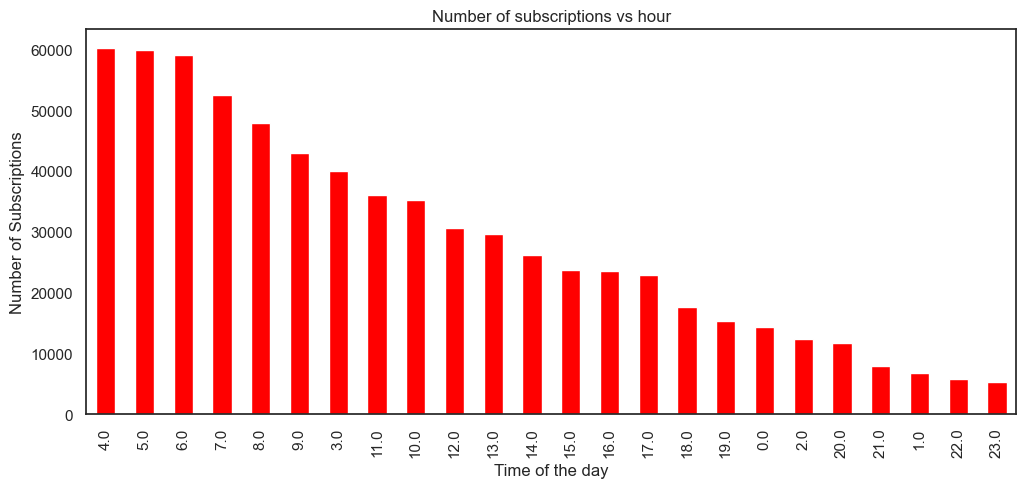

In [45]:
# what time of the day do users subscribe the most
hours = cdp_data['HOUR'].value_counts()
hours.plot(kind = 'bar', color = 'red', figsize = (12,5))
plt.xlabel('Time of the day')
plt.ylabel('Number of Subscriptions')
plt.title('Number of subscriptions vs hour')

Text(0.5, 1.0, 'Number of subscriptions vs days')

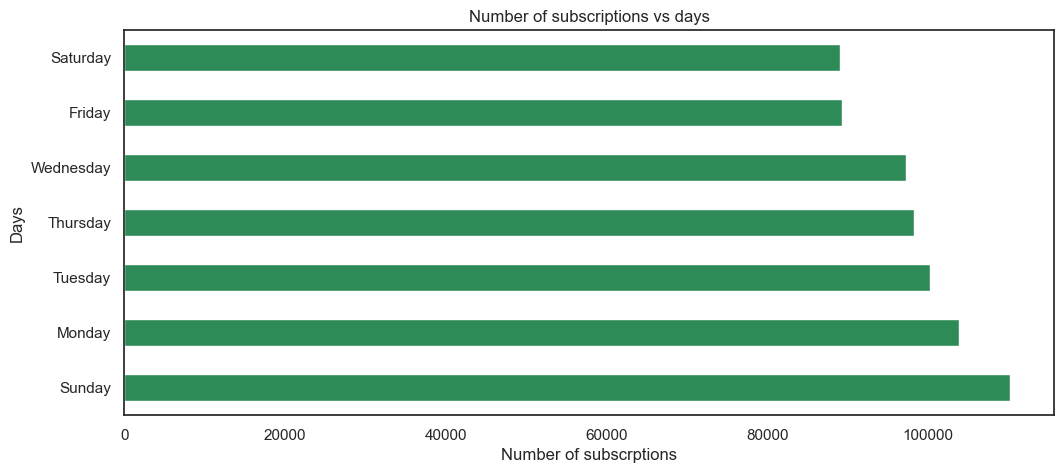

In [46]:
# which day do users subscribe the most
days = cdp_data['WEEKDAY'].value_counts()
days.plot(kind = 'barh', color = 'seagreen', figsize = (12, 5))
plt.xlabel('Number of subscrptions')
plt.ylabel('Days')
plt.title('Number of subscriptions vs days')

In [47]:
# Calculating the subscription_day
cdp_data['subscription_day'] = cdp_data['subscription_date'].dt.day_name()

# Funnel by day of the week
funnel_by_day = cdp_data.groupby('subscription_day').agg({
    'user_id': 'nunique',  # Users who visited (any interaction)
    'article_id': lambda x: cdp_data['article_id'].nunique(),  # Total number of articles available on the platform
    'subscribed_user_id': 'nunique'  # Users who subscribed
}).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], fill_value=0)

# Print results
print("Funnel Stages by Day of the Week:")
print(funnel_by_day)

Funnel Stages by Day of the Week:
                  user_id  article_id  subscribed_user_id
subscription_day                                         
Monday               3805        9449                3805
Tuesday              3583        9449                3583
Wednesday            3616        9449                3616
Thursday             3653        9449                3653
Friday               3326        9449                3326
Saturday             3283        9449                3283
Sunday               3635        9449                3635


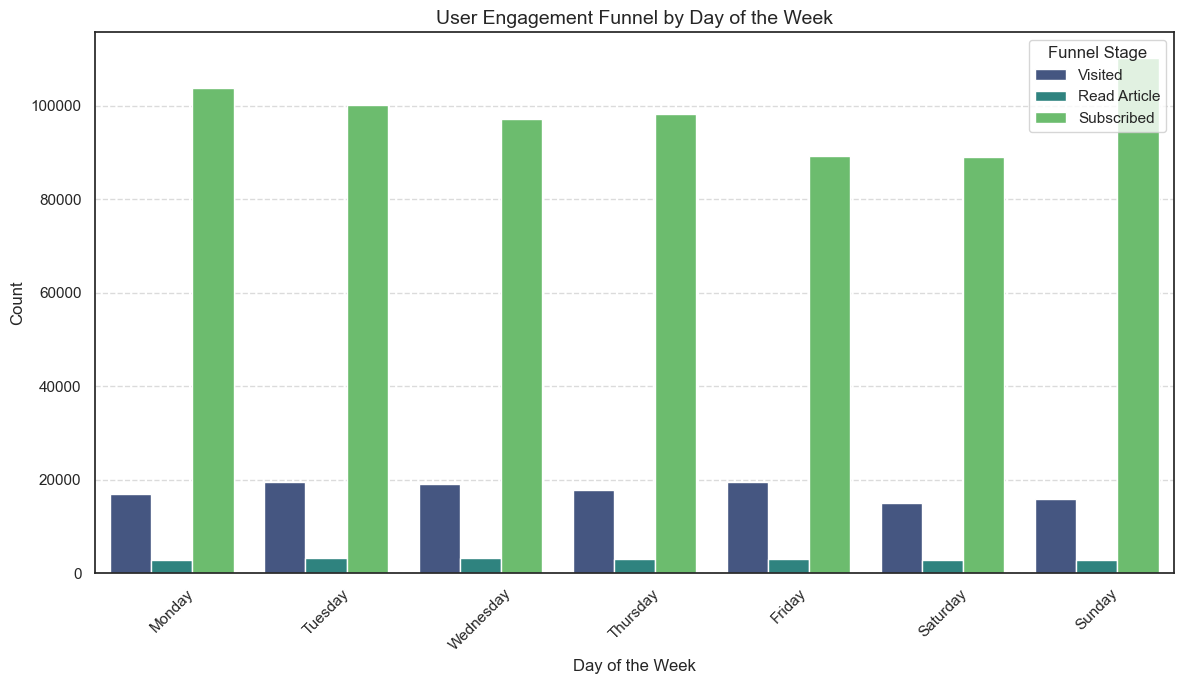

In [78]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Extract day names
cdp_data['session_day'] = cdp_data['session_creation_date'].dt.day_name()
cdp_data['sub_day'] = cdp_data['subscription_date'].dt.day_name()

# Visited: count of unique session_id per session day
visited = (
    cdp_data.groupby('session_day')['session_id']
    .nunique()
    .reindex(day_order, fill_value=0)
    .reset_index()
    .rename(columns={'session_day': 'Day', 'session_id': 'User Count'})
)
visited['Funnel Stage'] = 'Visited'

# Read Article: count of unique article_id per session day
read_article = (
    cdp_data[cdp_data['article_id'].notna()]
    .groupby('session_day')['article_id']
    .nunique()
    .reindex(day_order, fill_value=0)
    .reset_index()
    .rename(columns={'session_day': 'Day', 'article_id': 'User Count'})
)
read_article['Funnel Stage'] = 'Read Article'

# Subscribed: count of day_name occurrences in subscription records
subscribed = (
    cdp_data[cdp_data['subscription_date'].notna()]
    .groupby('sub_day')
    .size()
    .reindex(day_order, fill_value=0)
    .reset_index()
    .rename(columns={'sub_day': 'Day', 0: 'User Count'})
)
subscribed['Funnel Stage'] = 'Subscribed'

# Combine all three stages
funnel_melted = pd.concat([visited, read_article, subscribed], ignore_index=True)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(
    data=funnel_melted,
    x='Day',
    y='User Count',
    hue='Funnel Stage',
    palette='viridis',
    order=day_order
)
plt.title('User Engagement Funnel by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Funnel Stage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('weekly_engagement_funnel.png', dpi=300, bbox_inches='tight')
plt.show()

### Package type with the highest revenue based on top authors

<Axes: xlabel='authors'>

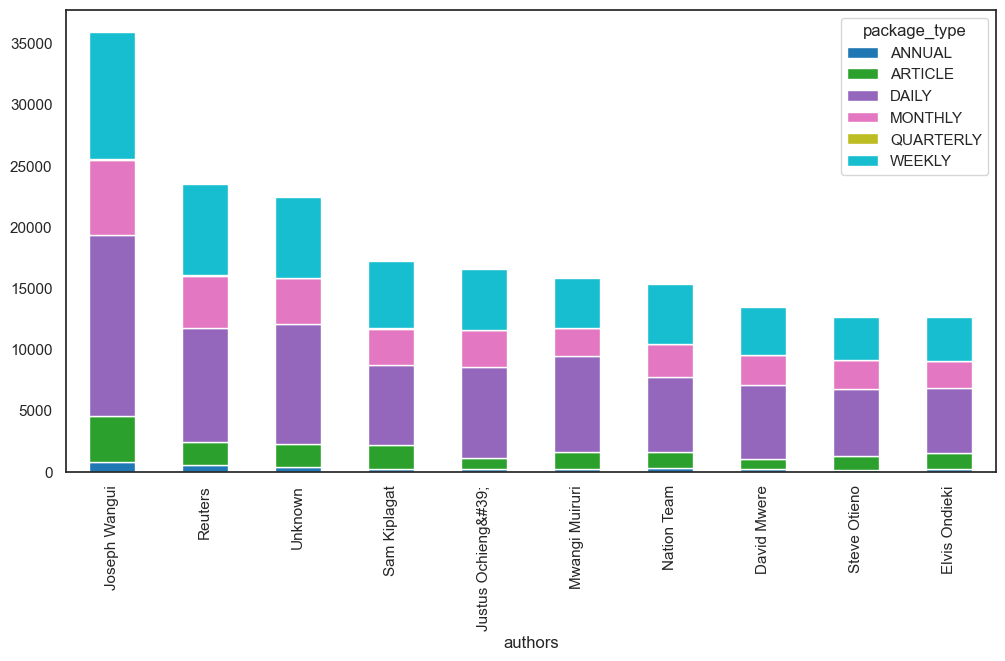

In [49]:
author_package_counts = cdp_data.groupby(['authors', 'package_type']).size().reset_index(name='count')
# Pivot data to get authors as index, package types as columns
pivot_table = author_package_counts.pivot(index='authors', columns='package_type', values='count').fillna(0)

top_authors = pivot_table.sum(axis=1).sort_values(ascending=False).head(10).index
pivot_table.loc[top_authors].plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')

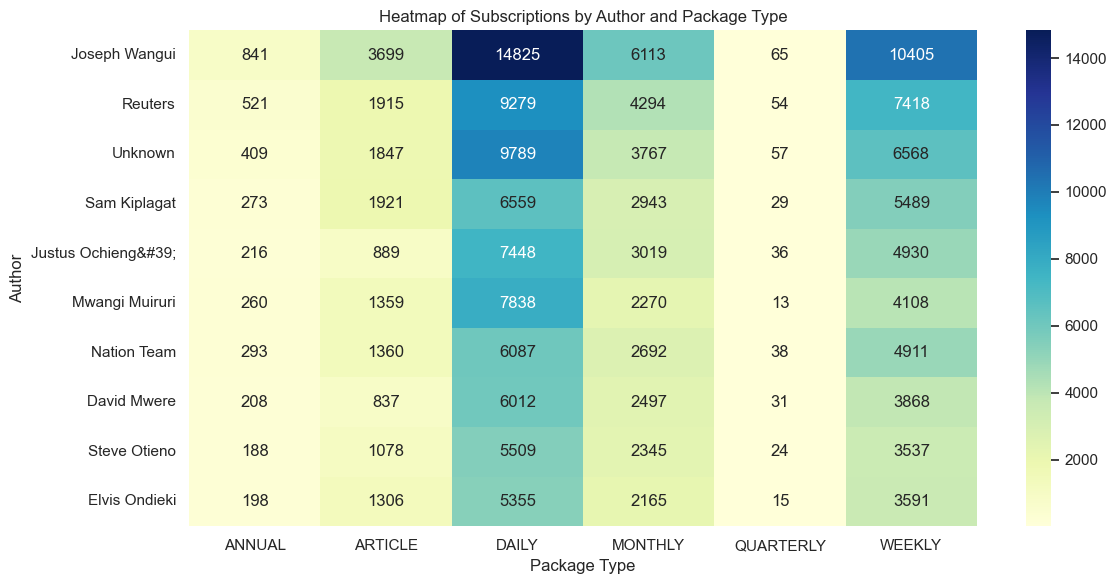

In [50]:
fig = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_table.loc[top_authors], annot=True, fmt='g', cmap='YlGnBu')
plt.title("Heatmap of Subscriptions by Author and Package Type")
plt.xlabel("Package Type")
plt.ylabel("Author")
plt.tight_layout()
plt.savefig('author_package_type_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

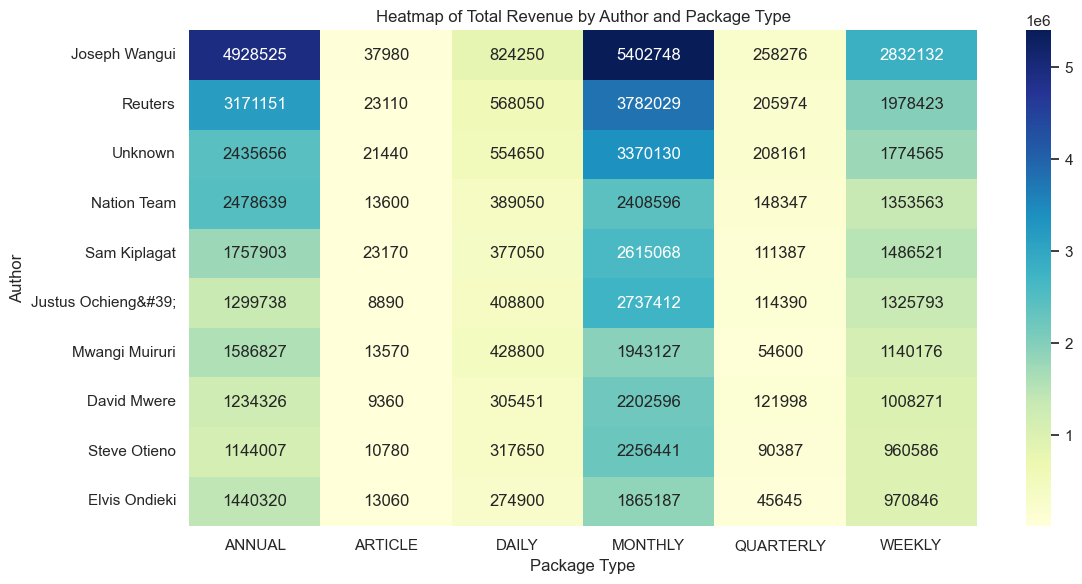

In [51]:
author_package_revenue = cdp_data.groupby(['authors', 'package_type'])['amount_paid'].sum().reset_index(name='total_revenue')

# Pivot
pivot_table = author_package_revenue.pivot(
    index='authors',
    columns='package_type',
    values='total_revenue'
).fillna(0)

top_authors = pivot_table.sum(axis=1).sort_values(ascending=False).head(10).index

# ─── Plot 2: Heatmap ───
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_table.loc[top_authors], annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title("Heatmap of Total Revenue by Author and Package Type")
ax.set_xlabel("Package Type")
ax.set_ylabel("Author")
plt.tight_layout()
plt.savefig('author_package_revenue_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# EDA on Location

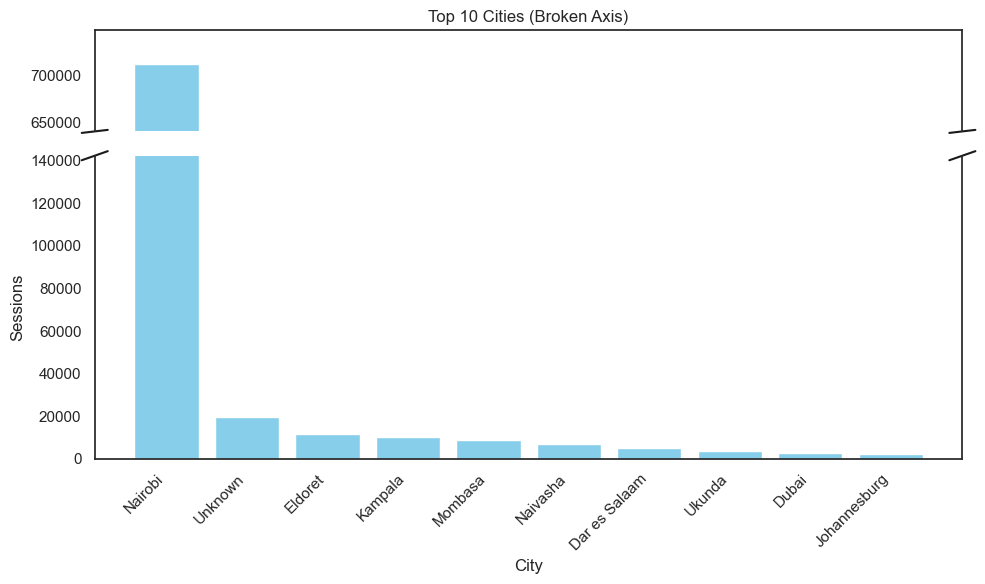

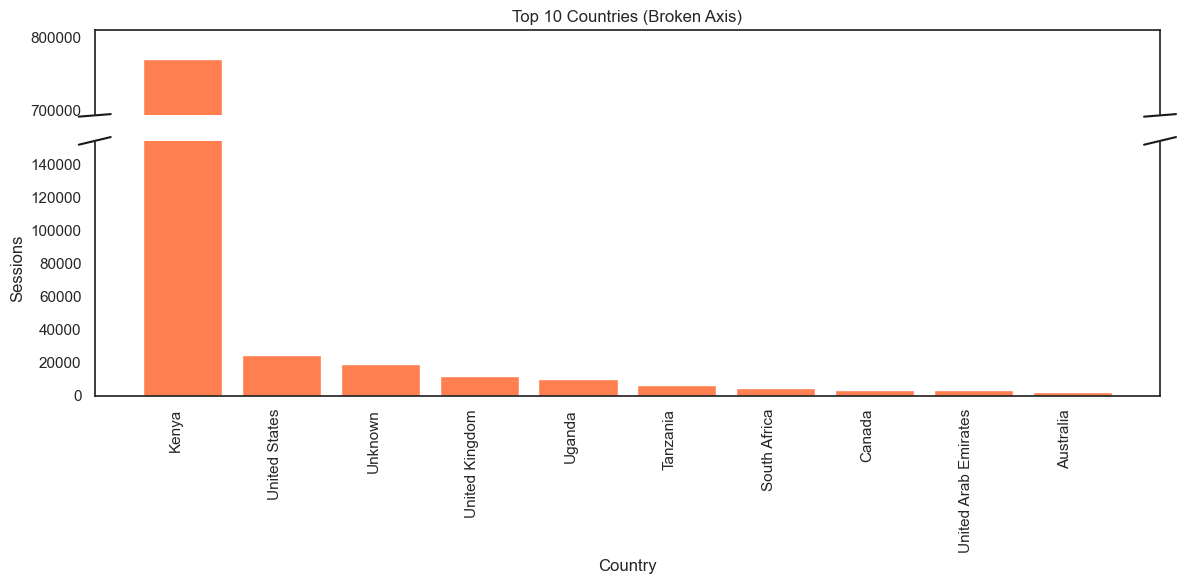

In [52]:
# Plot top cities with broken y-axis
if cdp_data['city'].nunique() > 1:
    top_cities = cdp_data['city'].value_counts().head(10)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 3]})

    # Upper part
    ax1.bar(top_cities.index, top_cities.values, color='skyblue')
    ax1.set_ylim(top_cities.max() * 0.9, top_cities.max() * 1.05)  # show only top part
    ax1.spines['bottom'].set_visible(False)
    ax1.tick_params(bottom=False)
    ax1.set_title("Top 10 Cities (Broken Axis)")

    # Lower part
    ax2.bar(top_cities.index, top_cities.values, color='skyblue')
    ax2.set_ylim(0, top_cities.max() * 0.2)  # show lower values
    ax2.spines['top'].set_visible(False)

    # Diagonal lines to indicate break
    d = .015
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    plt.xlabel("City")
    plt.ylabel("Sessions")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Repeat for countries
if cdp_data['country'].nunique() > 1:
    top_countries = cdp_data['country'].value_counts().head(10)

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6), gridspec_kw={'height_ratios': [1, 3]})

    ax1.bar(top_countries.index, top_countries.values, color='coral')
    ax1.set_ylim(top_countries.max() * 0.9, top_countries.max() * 1.05)
    ax1.spines['bottom'].set_visible(False)
    ax1.tick_params(bottom=False)
    ax1.set_title("Top 10 Countries (Broken Axis)")

    ax2.bar(top_countries.index, top_countries.values, color='coral')
    ax2.set_ylim(0, top_countries.max() * 0.2)
    ax2.spines['top'].set_visible(False)

    d = .015
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    plt.xlabel("Country")
    plt.ylabel("Sessions")
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.savefig('sessions_per_country.png', dpi=300, bbox_inches='tight')
    plt.savefig('sessions_per_city.png', dpi=300, bbox_inches='tight')
    plt.show()

# Engagement Analysis

In [53]:
cdp_data['purchase_date'] = pd.to_datetime(cdp_data['purchase_date'], errors='coerce')

In [54]:
cdp_data[['expiry_date', 'purchase_date']].dtypes

expiry_date      datetime64[us]
purchase_date    datetime64[us]
dtype: object

In [55]:
# Subscription duration
cdp_data['subscription_duration'] = (cdp_data['expiry_date'] - cdp_data['purchase_date']).dt.days

In [56]:
user_count_by_duration = cdp_data['subscription_duration'].value_counts().sort_index()
print(user_count_by_duration)

subscription_duration
0.0        1256
1.0      360390
2.0          11
6.0         284
7.0      196726
8.0          13
9.0         422
16.0          5
29.0        402
30.0       9009
31.0     103664
32.0         45
91.0       1378
364.0        35
365.0     14242
Name: count, dtype: int64


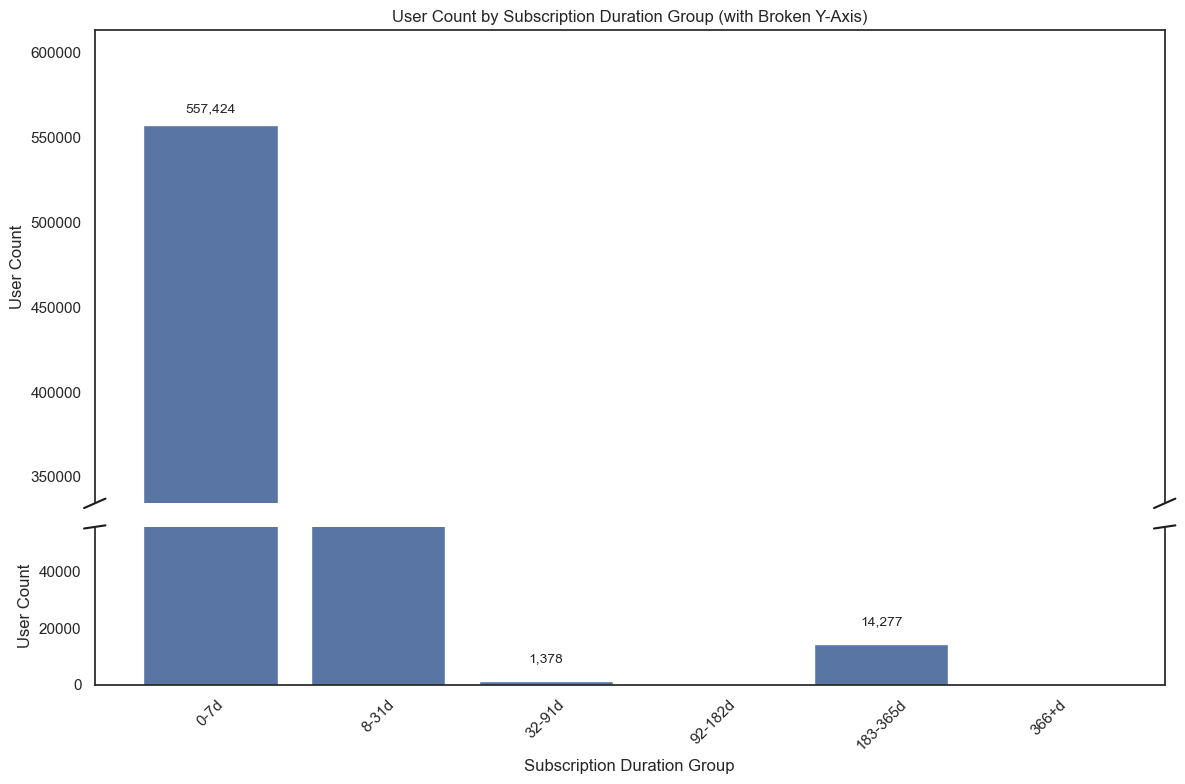

In [57]:
import matplotlib.ticker as mticker

# Define bins and labels 
bins = [0, 8, 32, 92, 183, 366,  np.inf]
labels = ['0-7d', '8-31d', '32-91d', '92-182d', '183-365d', '366+d']

# Create duration group column
cdp_data['duration_group'] = pd.cut(cdp_data['subscription_duration'], bins=bins, labels=labels, right=True)

# Count users in each group
duration_counts = cdp_data['duration_group'].value_counts().sort_index()

# Plot with broken y-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot on both axes
sns.barplot(x=duration_counts.index, y=duration_counts.values, ax=ax1)
sns.barplot(x=duration_counts.index, y=duration_counts.values, ax=ax2)

# Set y-axis limits (adjust based on your data)
top_ylim_low = duration_counts.max() * 0.6
top_ylim_high = duration_counts.max() + duration_counts.max() * 0.1
bottom_ylim_high = duration_counts.max() * 0.1

ax1.set_ylim(top_ylim_low, top_ylim_high)   # Top plot (high bars)
ax2.set_ylim(0, bottom_ylim_high)           # Bottom plot (low bars)

# Hide spines between plots
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Diagonal break marks
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-0.01, +0.01), (-0.01, +0.01), **kwargs)
ax1.plot((0.99, 1.01), (-0.01, +0.01), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-0.01, +0.01), (1 - 0.01, 1 + 0.01), **kwargs)
ax2.plot((0.99, 1.01), (1 - 0.01, 1 + 0.01), **kwargs)

# Add titles and labels
ax1.set_title('User Count by Subscription Duration Group (with Broken Y-Axis)')
ax2.set_xlabel('Subscription Duration Group')
ax1.set_ylabel('User Count')
ax2.set_ylabel('User Count')
# Add value labels on top of bars (for both axes)
for i, count in enumerate(duration_counts.values):
    label = f"{count:,}"  # format with comma

    # Add to top axis if visible
    if top_ylim_low <= count:
        ax1.text(i, count + duration_counts.max() * 0.01, label, ha='center', va='bottom', fontsize=10)

    # Add to bottom axis if visible and non-zero
    elif count > 0 and count <= bottom_ylim_high:
        ax2.text(i, count + duration_counts.max() * 0.01, label, ha='center', va='bottom', fontsize=10)

# Rotate x-axis labels
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
cdp_data['interaction_creation_date'] = pd.to_datetime(cdp_data['interaction_creation_date'], errors='coerce')
cdp_data['session_creation_date'] = pd.to_datetime(cdp_data['session_creation_date'], errors='coerce')

In [59]:
cdp_data[['session_creation_date', 'interaction_creation_date']].dtypes

session_creation_date        datetime64[us]
interaction_creation_date    datetime64[us]
dtype: object

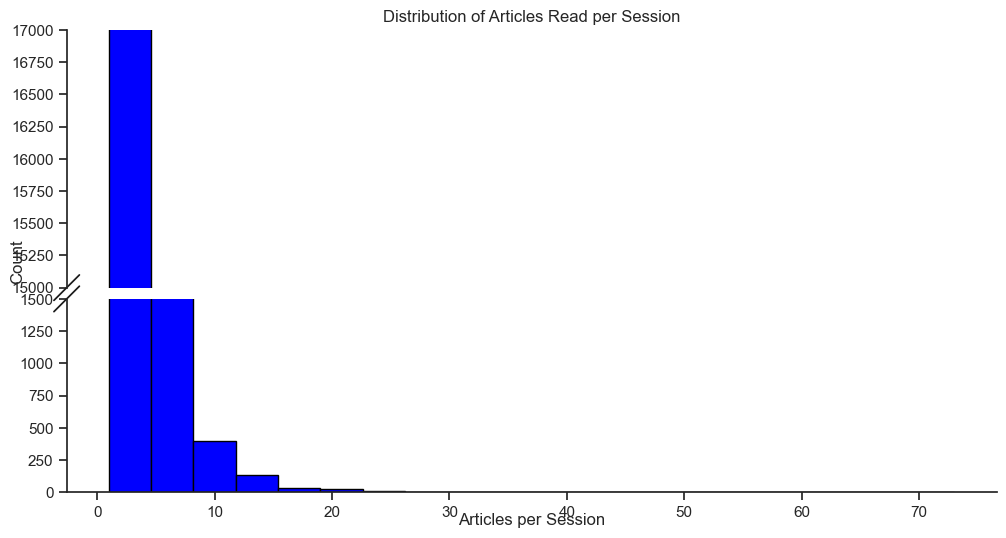

In [60]:
cdp_data['session_duration'] = (cdp_data['interaction_creation_date'] - cdp_data['session_creation_date']).dt.total_seconds() / 60
articles_per_session = cdp_data.groupby('session_id')['article_id'].nunique()

fig = plt.figure(figsize=(12,6))
bax = brokenaxes(ylims=((0, 1500), (15000, 17000)), hspace=.05)  # adjust ylims as needed
bax.hist(articles_per_session, bins=20, color='blue', edgecolor='black')
bax.set_xlabel('Articles per Session')
bax.set_ylabel('Count')
bax.set_title('Distribution of Articles Read per Session')
plt.show()

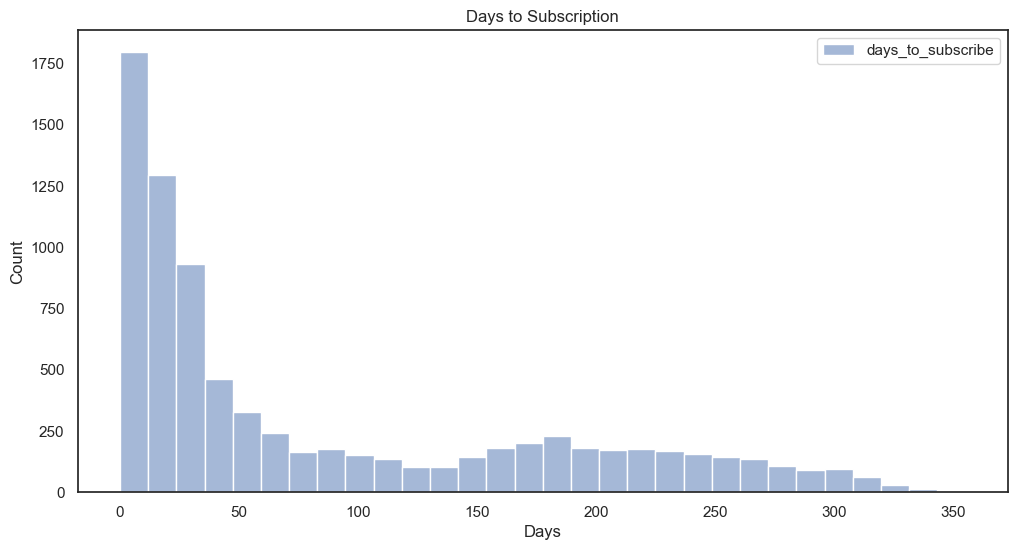

In [61]:
# Days to Subscription
user_first_session = cdp_data.groupby('user_id')['session_creation_date'].min()
subscription_times = cdp_data.groupby('subscribed_user_id')['subscription_date'].min()
time_to_sub = (subscription_times.to_frame('subscription_date').join(user_first_session.to_frame('first_session'), how='left'))

time_to_sub['days_to_subscribe'] = (time_to_sub['subscription_date'] - time_to_sub['first_session']).dt.days
time_to_sub['days_to_subscribe'] = time_to_sub['days_to_subscribe'].astype('Int64')
plt.figure(figsize=(12, 6))
sns.histplot(time_to_sub.dropna(), bins=30)
plt.title('Days to Subscription')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

# Pre-treatment for machine learning

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline  # use imblearn's Pipeline

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, classification_report, precision_recall_curve, accuracy_score,
                             mean_squared_error, ConfusionMatrixDisplay, precision_score, recall_score, confusion_matrix, roc_curve)

In [63]:
user_features = cdp_data.groupby('user_id').agg(
    session_count=('session_id', 'nunique'),
    articles_read=('article_id', 'nunique'),
    unique_authors_read=('authors', 'nunique'),        # breadth of content consumption
    unique_days_active=('session_creation_date',       # how many distinct days they visited
        lambda x: x.dt.date.nunique()),
    avg_session_gap_days=('session_creation_date',     # regularity of visits
        lambda x: x.sort_values().diff().dt.days.mean()),
    recency_days=('session_creation_date',             # days since last visit
        lambda x: (pd.Timestamp('today') - x.max()).days),
    country=('country', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
    subscription_date=('subscription_date', 'max')
)

In [64]:
user_features['is_subscribed'] = user_features['subscription_date'].notna().astype(int)
user_features.drop(columns=['subscription_date'], inplace=True)

In [65]:
user_features.head()

,session_count,articles_read,unique_authors_read,unique_days_active,avg_session_gap_days,recency_days,country,is_subscribed
user_id,,,,,,,,
67c93a0bc128f2cfe19dd3ac,1,1,1,1,NaN,377,Kenya,0
67c93a0cc128f2cfe19dd3ca,1,3,2,1,0.000000,392,Kenya,0
67c93a0fc128f2cfe19dd3ef,7,12,12,7,3.181818,336,Kenya,0
67c93a10c128f2cfe19dd3ff,9,11,8,8,4.375000,340,United States,0
67c93a12c128f2cfe19dd409,22,48,28,17,0.037081,348,Kenya,1


In [66]:
# Define features & target
features = [col for col in user_features.columns if col != 'is_subscribed']
target = 'is_subscribed'

X = user_features.drop(columns=[target])
y = user_features[target]

In [67]:
X.head()

,session_count,articles_read,unique_authors_read,unique_days_active,avg_session_gap_days,recency_days,country
user_id,,,,,,,
67c93a0bc128f2cfe19dd3ac,1,1,1,1,NaN,377,Kenya
67c93a0cc128f2cfe19dd3ca,1,3,2,1,0.000000,392,Kenya
67c93a0fc128f2cfe19dd3ef,7,12,12,7,3.181818,336,Kenya
67c93a10c128f2cfe19dd3ff,9,11,8,8,4.375000,340,United States
67c93a12c128f2cfe19dd409,22,48,28,17,0.037081,348,Kenya


In [68]:
# Encoding and Scaling
numeric_pipeline = SkPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = SkPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [69]:
categorical_cols = ['country']
numeric_cols = [col for col in features if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)
print("Categorical columns encoded:", categorical_cols)
print("Numeric columns scaled:", numeric_cols)

Categorical columns encoded: ['country']
Numeric columns scaled: ['session_count', 'articles_read', 'unique_authors_read', 'unique_days_active', 'avg_session_gap_days', 'recency_days']


In [70]:
print("Columns in X:", X.columns.tolist())

print("\nCategorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Columns in X: ['session_count', 'articles_read', 'unique_authors_read', 'unique_days_active', 'avg_session_gap_days', 'recency_days', 'country']

Categorical columns: ['country']

Numeric columns: ['session_count', 'articles_read', 'unique_authors_read', 'unique_days_active', 'avg_session_gap_days', 'recency_days']


In [71]:
#Train -Test Split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 2: Split the remaining 80% into train (75%) and validation (25%)
# This gives you roughly 60% train / 20% val / 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print("Train size:     ", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:      ", X_test.shape)

Train size:      (38163, 7)
Validation size: (12721, 7)
Test size:       (12722, 7)


# Baseline Models

In [72]:
base_models = [
    ('rf', RandomForestClassifier(
        class_weight='balanced', n_estimators=300, 
        max_depth=10, random_state=42)),
    ('gb', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, 
        max_depth=4, random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        eval_metric='logloss', random_state=42))
]


  Model: RF  |  Split: VALIDATION
  Accuracy  : 0.7389
  Precision : 0.2832
  Recall    : 0.6744
  ROC-AUC   : 0.7928
  RMSE      : 0.5109


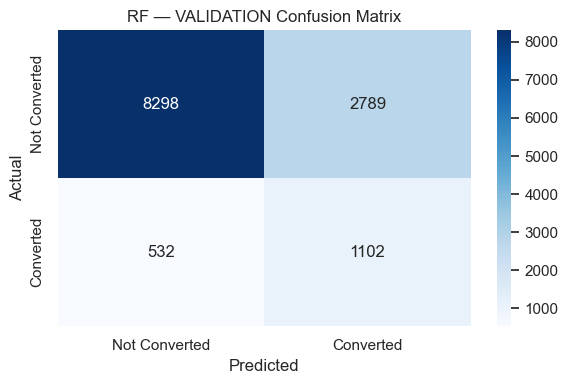


  Model: RF  |  Split: TEST
  Accuracy  : 0.7489
  Precision : 0.3019
  Recall    : 0.7277
  ROC-AUC   : 0.8175
  RMSE      : 0.5011


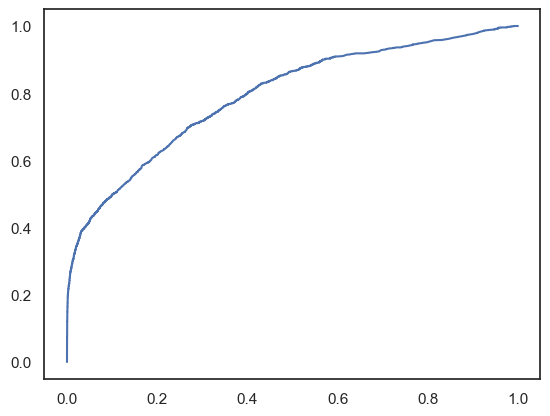

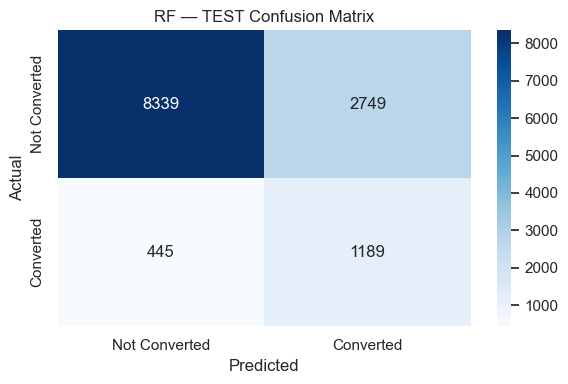


  Model: GB  |  Split: VALIDATION
  Accuracy  : 0.9060
  Precision : 0.8174
  Recall    : 0.3452
  ROC-AUC   : 0.8085
  RMSE      : 0.3066


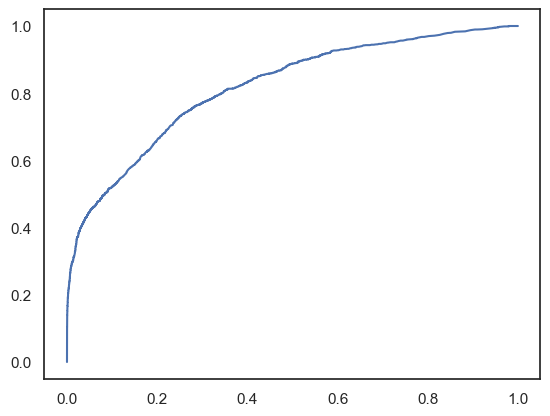

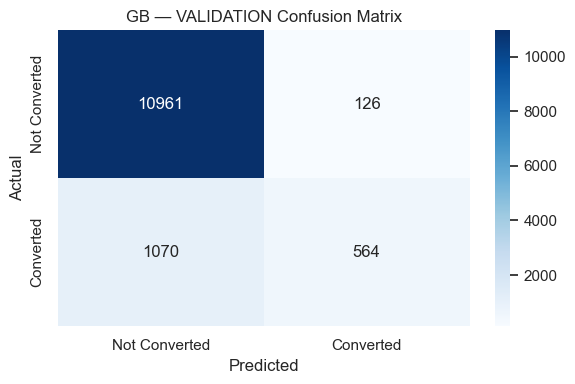


  Model: GB  |  Split: TEST
  Accuracy  : 0.9074
  Precision : 0.8184
  Recall    : 0.3586
  ROC-AUC   : 0.8294
  RMSE      : 0.3043


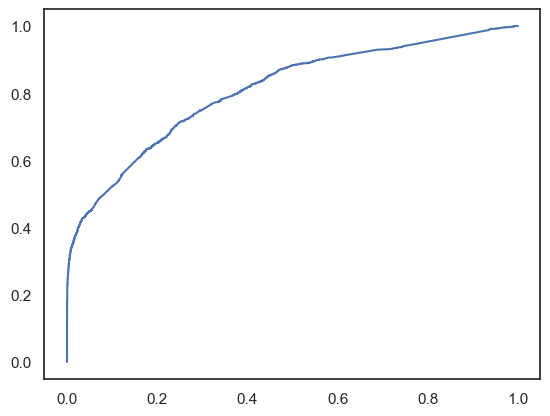

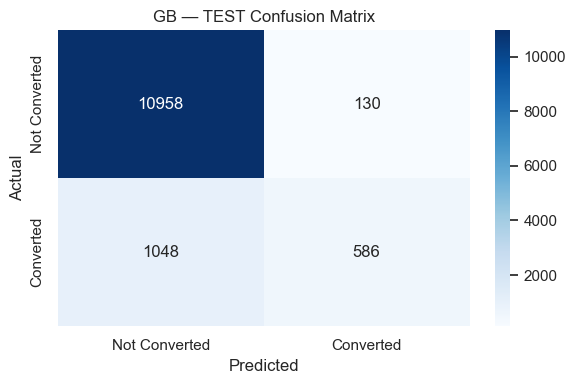


  Model: XGB  |  Split: VALIDATION
  Accuracy  : 0.7792
  Precision : 0.3217
  Recall    : 0.6487
  ROC-AUC   : 0.8027
  RMSE      : 0.4699


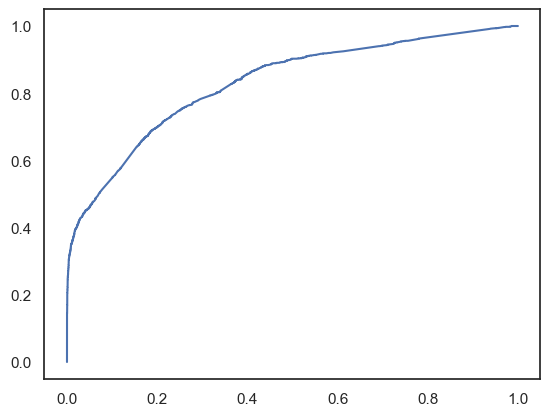

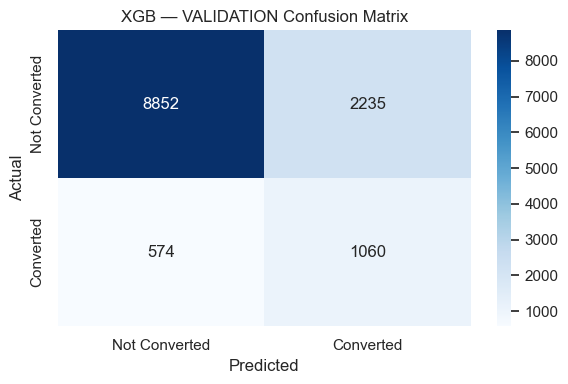


  Model: XGB  |  Split: TEST
  Accuracy  : 0.7905
  Precision : 0.3439
  Recall    : 0.6952
  ROC-AUC   : 0.8259
  RMSE      : 0.4577


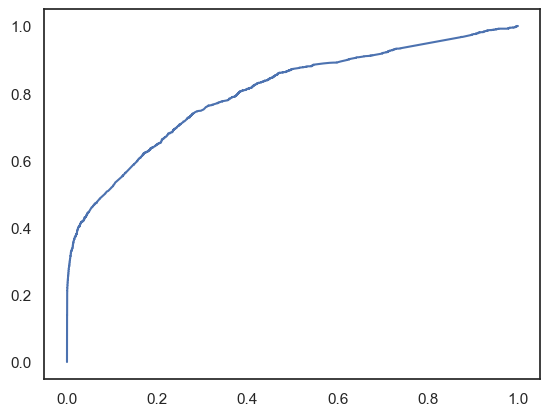

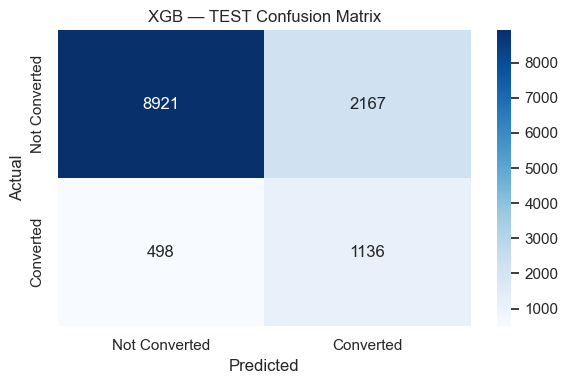

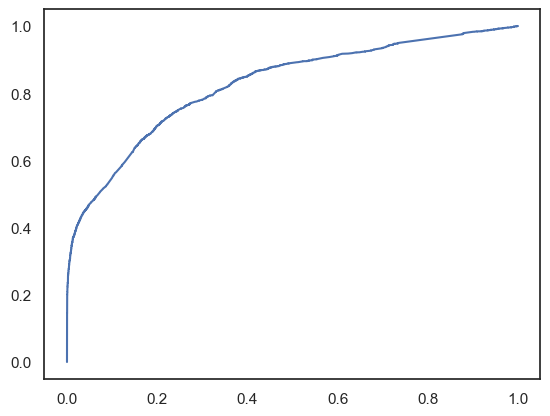

In [73]:
results = {}

for name, model in base_models:
    # ─── Build full pipeline (preprocessor + model) ───
    full_pipeline = SkPipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # ─── Train on X_train, validate on X_val ───
    full_pipeline.fit(X_train, y_train)

    # ─── Validation predictions ───
    y_val_pred  = full_pipeline.predict(X_val)
    y_val_proba = full_pipeline.predict_proba(X_val)[:, 1]

    # ─── Test predictions (final evaluation) ───
    y_test_pred  = full_pipeline.predict(X_test)
    y_test_proba = full_pipeline.predict_proba(X_test)[:, 1]

    # ─── Metrics (both splits) ───
    for split, y_true, y_pred, y_proba in [
        ('VALIDATION', y_val,  y_val_pred,  y_val_proba),
        ('TEST',       y_test, y_test_pred, y_test_proba)
    ]:
        acc     = accuracy_score(y_true, y_pred)
        prec    = precision_score(y_true, y_pred, zero_division=0)
        rec     = recall_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_proba)
        rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
        cm      = confusion_matrix(y_true, y_pred)

        # Save test metrics for summary table
        if split == 'TEST':
            results[name] = {
                'pipeline': full_pipeline,
                'Accuracy': acc, 'Precision': prec,
                'Recall': rec, 'ROC-AUC': roc_auc, 'RMSE': rmse
            }

        print(f"\n{'='*48}")
        print(f"  Model: {name.upper()}  |  Split: {split}")
        print(f"{'='*48}")
        print(f"  Accuracy  : {acc:.4f}")
        print(f"  Precision : {prec:.4f}")
        print(f"  Recall    : {rec:.4f}")
        print(f"  ROC-AUC   : {roc_auc:.4f}")
        print(f"  RMSE      : {rmse:.4f}")

        # ─── Confusion matrix ───
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)  # y_true not y_test
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Not Converted', 'Converted'],
                    yticklabels=['Not Converted', 'Converted'],
                    ax=ax
        )
        ax.set_title(f"{name.upper()} — {split} Confusion Matrix")  # includes split name
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        plt.tight_layout()
        plt.show()
        
        # ROC curve (add line to global plot)
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{name} - {split} (AUC={roc_auc_score(y_true, y_proba):.2f})")



In [74]:
# ─── Final summary table (Test set only) ───
print(f"\n{'='*65}")
print(f"  FINAL TEST SET COMPARISON")
print(f"{'='*65}")
print(f"{'Model':<10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'ROC-AUC':>10} {'RMSE':>8}")
print(f"{'-'*65}")
for name, m in results.items():
    print(f"{name.upper():<10} {m['Accuracy']:>10.4f} {m['Precision']:>10.4f} "
          f"{m['Recall']:>10.4f} {m['ROC-AUC']:>10.4f} {m['RMSE']:>8.4f}")


  FINAL TEST SET COMPARISON
Model        Accuracy  Precision     Recall    ROC-AUC     RMSE
-----------------------------------------------------------------
RF             0.7489     0.3019     0.7277     0.8175   0.5011
GB             0.9074     0.8184     0.3586     0.8294   0.3043
XGB            0.7905     0.3439     0.6952     0.8259   0.4577


In [75]:
def categorize(prob):
    if 0.50 <= prob <= 0.75:
        return "On the fence"
    elif prob > 0.75:
        return "Likely subscriber"
    else:
        return "Unlikely subscriber"

# Storage
metrics = []
on_the_fence_users = {}

In [76]:
category_counts = {}
on_the_fence_users = {}

for name, model in base_models:

    full_pipeline = SkPipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # ─── Train ───
    full_pipeline.fit(X_train, y_train)

    # ─── Validation predictions ───
    y_val_pred  = full_pipeline.predict(X_val)
    y_val_proba = full_pipeline.predict_proba(X_val)[:, 1]

    # ─── Test predictions ───
    y_test_pred  = full_pipeline.predict(X_test)
    y_test_proba = full_pipeline.predict_proba(X_test)[:, 1]  

    # Use y_test_pred and y_test_proba (not y_pred / y_proba)
    comparison_df = pd.DataFrame({
        "User_ID":        X_test.index,
        "Actual":         y_test.values,
        "Predicted":      y_test_pred,       
        "Predicted_Prob": y_test_proba,       
        "Category":       [categorize(p) for p in y_test_proba]  
    })

    # ─── Store category counts ───
    category_counts[name] = comparison_df["Category"].value_counts()

    print(f"\n{'='*45}")
    print(f"  Model: {name.upper()}")
    print(f"{'='*45}")
    print(f"\nFirst 10 Predictions:")
    print(comparison_df.head(10))
    print(f"\nCategory Distribution:")
    print(comparison_df["Category"].value_counts())

    # ─── Save on the fence users ───
    on_the_fence_users[name] = comparison_df.loc[
        comparison_df["Category"] == "On the fence", "User_ID"
    ]
    print(f"\nOn the fence users: {len(on_the_fence_users[name])}")

    # Feature importance (tree models)
    if hasattr(model, "feature_importances_"):
    # Get feature names AFTER preprocessing, not from raw X
        try:
            feature_names = pipeline.named_steps['prep'].get_feature_names_out()
        except AttributeError:
            # fallback if get_feature_names_out not available
            num_features = numeric_cols
            cat_features = pipeline.named_steps['prep'] \
                               .named_transformers_['cat'] \
                               .named_steps['encoder'] \
                               .get_feature_names_out(categorical_cols).tolist()
            feature_names = num_features + cat_features

        feat_imp = pd.DataFrame({
            "Feature":    feature_names,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(x="Importance", y="Feature", 
                    data=feat_imp.head(10),   # top 20 only, avoids clutter
                    palette="viridis")
        plt.title(f"{name} — Top 10 Feature Importances")
        plt.tight_layout()
        plt.show()


  Model: RF

First 10 Predictions:
                    User_ID  Actual  Predicted  Predicted_Prob  \
0  67cb3f0cc128f2cfe1d33cee       0          0        0.450130   
1  67fbb7147218b3a140a48d8d       1          1        0.510323   
2  67cd8010c128f2cfe100025e       0          0        0.228288   
3  683faaae62244400c37d6270       0          1        0.533445   
4  683e6e6c62244400c3687de2       0          1        0.500408   
5  67c94524c128f2cfe1a00f76       0          0        0.395117   
6  67cbc2b6c128f2cfe1d91519       0          0        0.251564   
7  67c98acec128f2cfe1aadbb2       0          0        0.257549   
8  67ceb3a7286e063c3c239be2       0          0        0.225837   
9  67ca822ec128f2cfe1be9fa7       0          0        0.259123   

              Category  
0  Unlikely subscriber  
1         On the fence  
2  Unlikely subscriber  
3         On the fence  
4         On the fence  
5  Unlikely subscriber  
6  Unlikely subscriber  
7  Unlikely subscriber  
8  Unlikely 

NameError: name 'pipeline' is not defined

In [ ]:
category_counts_df = pd.DataFrame(category_counts).fillna(0).astype(int)
print("\nCategory counts for all models:")
print(category_counts_df)

# Meta model

In [ ]:
smote_enn = SMOTEENN(random_state=42)

base_models = [
    ('rf', RandomForestClassifier(
        class_weight='balanced', n_estimators=300, 
        max_depth=10, random_state=42)),
    ('gb', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, 
        max_depth=4, random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        eval_metric='logloss', random_state=42))
]

meta_model = LogisticRegression(C=0.1, max_iter=1000)  # regularize the meta-model

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smoteenn', smote_enn),
    ('model', stack_model)
])

In [ ]:
# Option 1: Regularized LR (safer, less prone to overfitting on meta-features)
meta_model = LogisticRegression(C=0.05, max_iter=1000)

# Option 2: A light GBM as the meta-model (more expressive)
#meta_model = GradientBoostingClassifier(n_estimators=50, max_depth=2, learning_rate=0.1)

In [ ]:
# Fit on training set only
pipeline.fit(X_train, y_train)

# Get probabilities on the VALIDATION set (for threshold tuning)
y_proba_val = pipeline.predict_proba(X_val)[:, 1]

# Now tune threshold using validation set — NOT test set
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold (from validation set):", best_threshold)

In [ ]:
# Get probabilities on TEST set
y_proba_test = pipeline.predict_proba(X_test)[:, 1]

# Apply the threshold found from the validation set
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)

from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_proba_test))
print("\nOptimized Threshold Results:\n")
print(classification_report(y_test, y_pred_optimal))

In [ ]:
print("Class distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

# Model Optimization

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import numpy as np

# --- Step 1: Compute imbalance ratio for XGBoost ---
imbalance_ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

# --- Step 2: Base models with class imbalance handling ---
base_models = [
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=300, max_depth=10, random_state=42)),
    ('gb', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, random_state=42)),
    ('xgb', XGBClassifier(
        scale_pos_weight=6.78,    n_estimators=500,
        learning_rate=0.03,        # slower learning = better generalization
        max_depth=4,               # shallower trees reduce majority class bias
        min_child_weight=5,        # requires more samples to make a split
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='aucpr',       # optimize for precision-recall, not logloss
        random_state=42))
]

meta_model = LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

# --- Step 4: Full pipeline with SMOTE ---
#smote = SMOTE(random_state=42)
smote = SMOTE(
    sampling_strategy=0.5,  # make minority class 50% the size of majority
    random_state=42
)
pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', smote),
    ('model', stack_model)
])

# --- Step 5: Fit on training set ---
pipeline.fit(X_train, y_train)

# --- Step 6: Threshold tuning on VALIDATION set ---
y_proba_val = pipeline.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Floor the threshold at 0.3 to avoid the near-zero collapse
min_threshold = 0.30
viable_mask = thresholds >= min_threshold
if viable_mask.any():
    viable_thresholds = thresholds[viable_mask]
    viable_f1 = f1_scores[np.where(viable_mask)[0]]
    best_threshold = viable_thresholds[np.argmax(viable_f1)]
else:
    best_threshold = 0.5

print(f"Best threshold: {best_threshold:.4f}")

# --- Step 7: Final evaluation on TEST set ---
y_proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)

print("\nROC-AUC:", roc_auc_score(y_test, y_proba_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_optimal))

In [ ]:
# --- Step 1: Imbalance ratio (dynamic, not hardcoded) ---
imbalance_ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

# --- Step 2: Base models ---
# SMOTE handles imbalance in the pipeline, so avoid double-correcting:
# - Remove class_weight='balanced' from RF (SMOTE already balances)
# - Use dynamic scale_pos_weight from actual ratio
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42)),
    ('gb', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42)),
    ('xgb', XGBClassifier(
        scale_pos_weight=imbalance_ratio,  # dynamic, not hardcoded
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='aucpr',
        random_state=42))
]

# --- Step 3: Meta-model ---
# No class_weight here — SMOTE already handled it upstream
# Use a slightly more expressive meta-model
meta_model = LogisticRegression(C=0.1, max_iter=1000)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    passthrough=True  # also passes original features to meta-model
)

# --- Step 4: SMOTEENN instead of plain SMOTE ---
# SMOTE generates synthetic samples; ENN removes noisy borderline ones
# Net effect: cleaner decision boundary than SMOTE alone
smote_enn = SMOTEENN(
    smote=SMOTE(sampling_strategy=0.5, random_state=42),
    random_state=42
)

pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('resample', smote_enn),   # cleaner than plain SMOTE
    ('model', stack_model)
])

# --- Step 5: Fit ---
pipeline.fit(X_train, y_train)

# --- Step 6: Threshold tuning on VALIDATION set ---
y_proba_val = pipeline.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Scan thresholds between 0.2 and 0.7 — don't hard-floor at 0.3
min_threshold = 0.20
max_threshold = 0.70
viable_mask = (thresholds >= min_threshold) & (thresholds <= max_threshold)

if viable_mask.any():
    viable_thresholds = thresholds[viable_mask]
    viable_f1 = f1_scores[np.where(viable_mask)[0]]
    best_idx = np.argmax(viable_f1)
    best_threshold = viable_thresholds[best_idx]
    print(f"Best threshold : {best_threshold:.4f}")
    print(f"Val F1 at best : {viable_f1[best_idx]:.4f}")
else:
    best_threshold = 0.5
    print("No viable threshold found, defaulting to 0.5")

# Show precision-recall tradeoff at the chosen threshold
val_pred_tuned = (y_proba_val >= best_threshold).astype(int)
print(f"\nValidation Report (threshold={best_threshold:.2f}):")
print(classification_report(y_val, val_pred_tuned))

# --- Step 7: Final evaluation on TEST set ---
y_proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)

print(f"\nTest ROC-AUC : {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"\nTest Classification Report (threshold={best_threshold:.2f}):\n")
print(classification_report(y_test, y_pred_optimal))

# --- Step 8: Precision-Recall curve plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, color='blue', label='PR Curve')
ax.axvline(
    recall[np.where(thresholds >= best_threshold)[0][0]],
    color='red', linestyle='--',
    label=f'Best threshold={best_threshold:.2f}'
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.show()